# Longitudinal trajectories — symmetry/plasticity project

Tests whether cross-sectional findings extend longitudinally. Four measures, mirroring cross-sectional analyses:

1. **Peak distance** to control centroid (2D, x×y; Grill-Spector & Weiner 2014)
2. **Sum-selectivity** (log10 sum_selec_norm)
3. **Distinctiveness** (Liu Fisher-z; lower = more distinct)
4. **TFCE follow-up** — persistence (A) + preference shifts (B), within the 4 cross-sectional TFCE survivor clusters

Measures 1–3 read from `peak_coords_mni.csv` directly. Measure 4 reads two CSVs from `longitudinal_tfce_trajectories.py`.

**Longitudinal sample (OTC, ≥2 sessions):** sub-004, sub-008, sub-010, sub-021 (TC), sub-079. Sub-108 ses-02 pending MNI registration.

**TC pre/post handling:** ses-01 (pre) vs ses-03 (stable post). ses-02 (~8mo post, flagged unreliable) skipped per PI.

**Caveats to keep in mind:**
- Other 5 patients are post→post only (different question: stability/maturation, not pre/post reorganization)
- TC pre-surgical RH already atypical (Liu 2025): not a clean baseline
- n=1 for TC pre/post → directional shifts, not group inference; Crawford-Howell against control distribution

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir, git_dir

# ── Paths ──────────────────────────────────────────────────────────────
PEAK_CSV       = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'
SUB_INFO_CSV   = Path(git_dir) / 'sub_info.csv'
TFCE_LONG_DIR  = Path(processed_dir) / 'group_results' / 'longitudinal' / 'tfce'
FIG_DIR        = Path(git_dir) / 'C_results' / 'figures' / 'longitudinal'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────
PRIMARY_PARCELS = ['face_FFA', 'house_PPA', 'object_LOC', 'word_VWFA']
PARCEL_LABEL    = {'face_FFA':'FFA', 'house_PPA':'PPA', 'object_LOC':'LOC', 'word_VWFA':'VWFA'}
WTA_THRESH      = 2.326
N_PERM          = 10_000
RNG_SEED        = 42

# Longitudinal OTC patients (will be filtered against actual peak_coords below)
LONG_OTC_TARGET = ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079', 'sub-108']

# TC-specific session handling
TC_SUB     = 'sub-021'
TC_PRE_SES = 1   # pre-surgical
TC_POST_SES = 3  # stable post (skip ses-02)

# Plot styling
GROUP_COLORS = {'control': '#888888', 'OTC': '#d62728', 'TC_pre': '#1f77b4', 'TC_post': '#d62728'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

In [2]:
# ── Load + dedupe peak_coords ──────────────────────────────────────────
peak = pd.read_csv(PEAK_CSV)
# Each (sub, ses, category, hemi) has multiple rows (one per pair). For
# distance/sum-sel/distinctiveness we want one row per (sub, ses, category, hemi).
peak_u = peak.drop_duplicates(subset=['subject_id', 'session', 'category', 'hemi']).copy()

info = pd.read_csv(SUB_INFO_CSV)
info['session']    = info['ses'].str.replace('ses-', '').astype(int)
info['subject_id'] = info['sub']

# ── Longitudinal subject sets actually present in peak_coords ───────────
ses_counts  = peak_u.groupby('subject_id')['session'].nunique()
long_otc    = sorted([s for s in LONG_OTC_TARGET
                      if s in ses_counts.index and ses_counts[s] >= 2])
long_ctrl   = sorted([s for s, n in ses_counts.items()
                      if peak_u[peak_u['subject_id']==s]['group'].iloc[0] == 'control' and n >= 2])

# Controls reference (first session per control, for cross-sectional comparison)
first_ses = peak_u[peak_u['group']=='control'].groupby('subject_id')['session'].min()
ctrl_xs   = peak_u.merge(first_ses.rename('fs'), on='subject_id')
ctrl_xs   = ctrl_xs[(ctrl_xs['group']=='control') & (ctrl_xs['session']==ctrl_xs['fs'])]

print(f'Longitudinal OTC patients (≥2 ses in peak_coords): {long_otc}')
print(f'  Missing from target: {sorted(set(LONG_OTC_TARGET) - set(long_otc))}')
print(f'Longitudinal controls (≥2 ses): n={len(long_ctrl)}')
print(f'Cross-sectional control reference (first session): n={ctrl_xs["subject_id"].nunique()}')

# Check TC ses-01 presence
tc_sessions = sorted(peak_u[peak_u['subject_id']==TC_SUB]['session'].unique().tolist())
print(f'\nTC ({TC_SUB}) sessions in peak_coords: {tc_sessions}')
if TC_PRE_SES not in tc_sessions:
    warnings.warn(f'TC ses-{TC_PRE_SES:02d} NOT in peak_coords — pre/post analyses will skip. '
                  'Re-run liu_recreation_csv_v2.py with empty PRE_SURGERY_SESSIONS dict.')

Longitudinal OTC patients (≥2 ses in peak_coords): ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079', 'sub-108']
  Missing from target: []
Longitudinal controls (≥2 ses): n=8
Cross-sectional control reference (first session): n=38

TC (sub-021) sessions in peak_coords: [1, 2, 3]


In [3]:
# ── Helpers ───────────────────────────────────────────────────────────
def crawford_t(score, ctrl_values):
    """Crawford & Howell (1998) modified t-test for single case vs control sample.
    Returns (t, df, p_two_tailed, z_equivalent).
    """
    ctrl = np.asarray(ctrl_values, dtype=float)
    ctrl = ctrl[~np.isnan(ctrl)]
    n  = len(ctrl)
    m  = ctrl.mean()
    sd = ctrl.std(ddof=1)
    if sd == 0 or n < 3:
        return np.nan, n-1, np.nan, np.nan
    t  = (score - m) / (sd * np.sqrt((n + 1) / n))
    df = n - 1
    p  = 2 * (1 - stats.t.cdf(np.abs(t), df))
    z  = (score - m) / sd
    return t, df, p, z


def control_ref_band(ctrl_vals):
    """Return (mean, sd, lo, hi) for control reference band (mean ± 2 SD)."""
    v = np.asarray(ctrl_vals, dtype=float)
    v = v[~np.isnan(v)]
    if len(v) < 3:
        return np.nan, np.nan, np.nan, np.nan
    m, sd = v.mean(), v.std(ddof=1)
    return m, sd, m - 2*sd, m + 2*sd


def patient_intact_hemi(sub):
    """Return 'l' or 'r' for the intact hemisphere of an OTC patient."""
    row = info[info['subject_id'] == sub].iloc[0]
    return 'l' if row['intact_hemi'] == 'left' else 'r'

## Measure 1: Peak distance to control centroid (2D)

For each (parcel × hemi), compute control centroid as mean (peak_x_mni, peak_y_mni) across control first sessions. Per (subject × session), Euclidean distance from each peak to that centroid. Z dropped per Grill-Spector & Weiner 2014 — primarily anatomical noise in VOTC.

**Hypothesis:** patient peaks farther from control centroid post-resection; trajectories show drift or stability over time.

In [4]:
# ── Compute control centroids (parcel × hemi) ──────────────────────────
centroids = {}
for parcel in PRIMARY_PARCELS:
    for hemi in ('l', 'r'):
        rows = ctrl_xs[(ctrl_xs['category']==parcel) & (ctrl_xs['hemi']==hemi)]
        if len(rows) >= 3:
            cx, cy = rows['peak_x_mni'].mean(), rows['peak_y_mni'].mean()
            centroids[(parcel, hemi)] = (cx, cy, rows['peak_x_mni'].values, rows['peak_y_mni'].values)

def peak_distance_2d(row, centroid):
    cx, cy, _, _ = centroid
    if pd.isna(row['peak_x_mni']) or pd.isna(row['peak_y_mni']):
        return np.nan
    return float(np.sqrt((row['peak_x_mni'] - cx)**2 + (row['peak_y_mni'] - cy)**2))

# ── Build long-form distance df ────────────────────────────────────────
dist_rows = []
for _, r in peak_u.iterrows():
    key = (r['category'], r['hemi'])
    if key not in centroids:
        continue
    d = peak_distance_2d(r, centroids[key])
    if not np.isnan(d):
        dist_rows.append({
            'subject_id': r['subject_id'], 'session': r['session'],
            'group': r['group'], 'intact_hemi': r.get('intact_hemi', ''),
            'parcel': r['category'], 'hemi': r['hemi'], 'distance': d,
        })
dist_df = pd.DataFrame(dist_rows)
print(f'Distance rows: {len(dist_df):,}')

Distance rows: 584


In [5]:
# ── TC pre/post: Crawford-Howell per parcel (intact RH only) ───────────
if TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('TC pre/post — Peak distance to control centroid (intact RH)')
    print('=' * 72)
    print(f'{"Parcel":<12} {"Pre dist":>10} {"Post dist":>10} {"Δ":>8} '
          f'{"Ctrl M":>8} {"p_pre":>8} {"p_post":>8}')
    print('-' * 72)
    for parcel in PRIMARY_PARCELS:
        tc = dist_df[(dist_df['subject_id']==TC_SUB) & (dist_df['parcel']==parcel) & (dist_df['hemi']=='r')]
        pre  = tc[tc['session']==TC_PRE_SES]['distance']
        post = tc[tc['session']==TC_POST_SES]['distance']
        if pre.empty or post.empty:
            continue
        ctrl_d = dist_df[(dist_df['group']=='control') & (dist_df['parcel']==parcel) &
                         (dist_df['hemi']=='r')]
        # First session per control only
        ctrl_d = ctrl_d.merge(first_ses.rename('fs'), on='subject_id')
        ctrl_d = ctrl_d[ctrl_d['session']==ctrl_d['fs']]['distance'].values
        _, _, p_pre,  _ = crawford_t(pre.iloc[0],  ctrl_d)
        _, _, p_post, _ = crawford_t(post.iloc[0], ctrl_d)
        print(f'{parcel:<12} {pre.iloc[0]:>10.2f} {post.iloc[0]:>10.2f} '
              f'{post.iloc[0]-pre.iloc[0]:>+8.2f} {np.mean(ctrl_d):>8.2f} '
              f'{p_pre:>8.3f} {p_post:>8.3f}')
else:
    print(f'TC pre/post not available (ses-{TC_PRE_SES:02d} or ses-{TC_POST_SES:02d} missing).')

TC pre/post — Peak distance to control centroid (intact RH)
Parcel         Pre dist  Post dist        Δ   Ctrl M    p_pre   p_post
------------------------------------------------------------------------
face_FFA           9.19      10.61    +1.43     9.00    0.975    0.789
house_PPA         21.63      21.01    -0.63    21.15    0.940    0.982
object_LOC         8.48      11.86    +3.38     6.96    0.737    0.282
word_VWFA          1.28       3.10    +1.82     9.38    0.200    0.318


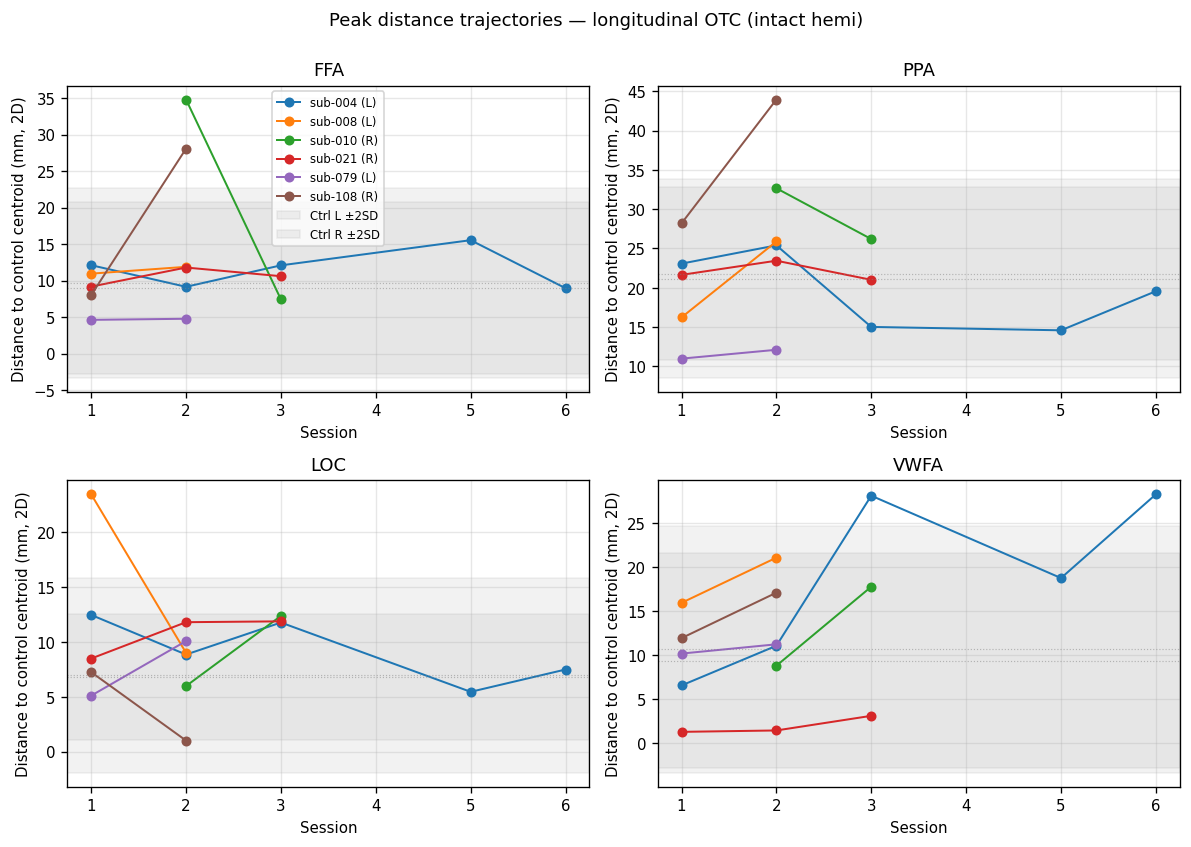

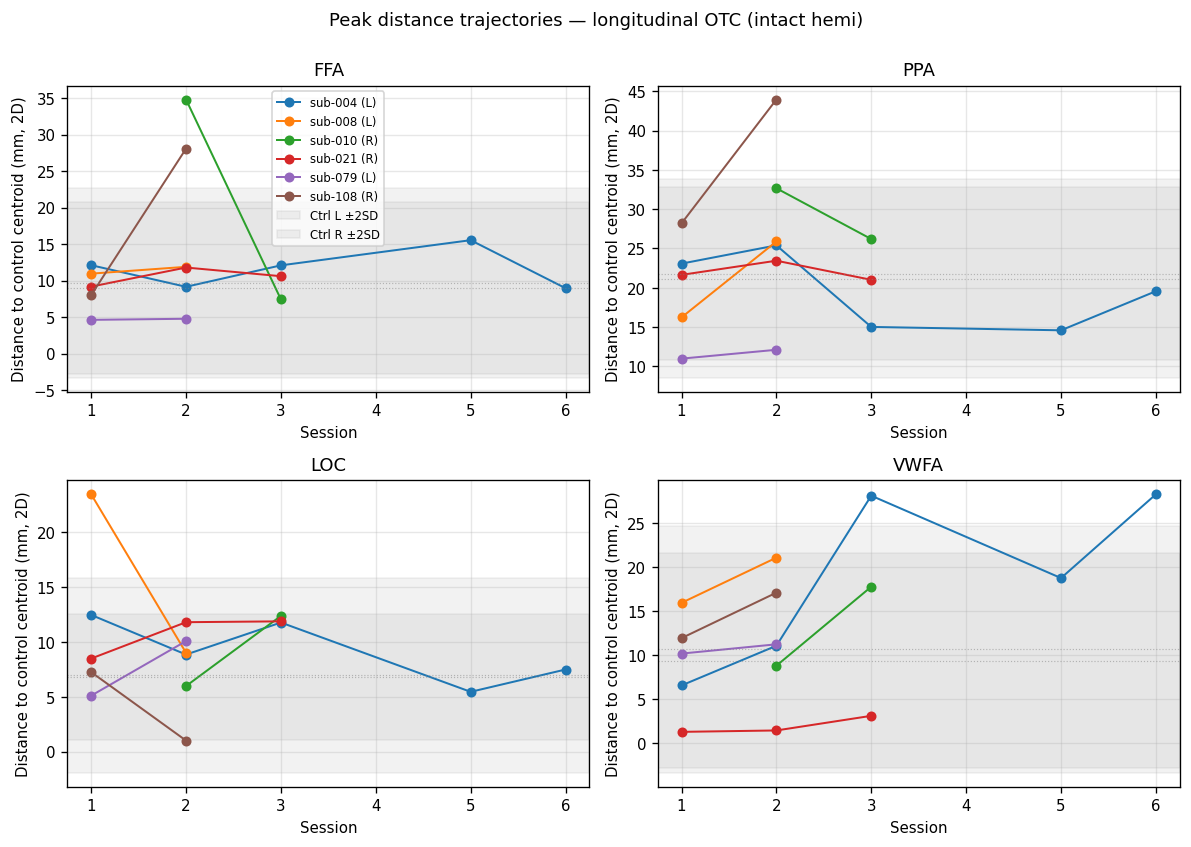

In [6]:
# ── Trajectory plot: all longitudinal OTC × primary parcels in intact hemi ──
def plot_trajectories(metric_df, value_col, ylabel, title, fname,
                      higher_is_better=False):
    """One panel per primary parcel. X = session. Y = metric.
    Control band = mean ± 2 SD across control first sessions, in the
    matched hemi per patient (so each patient line plotted against its
    own intact-hemi reference band).
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
    for ax, parcel in zip(axes.flat, PRIMARY_PARCELS):
        # Plot each patient in their intact hemi
        for sub in long_otc:
            hemi = patient_intact_hemi(sub)
            p = metric_df[(metric_df['subject_id']==sub) &
                          (metric_df['parcel']==parcel) &
                          (metric_df['hemi']==hemi)].sort_values('session')
            if p.empty:
                continue
            label = f'{sub} ({hemi.upper()})'
            ax.plot(p['session'], p[value_col], '-o', label=label,
                    markersize=5, linewidth=1.2)
        # Control band (overlay both hemis as separate bands? or pool?)
        # Use intact-hemi pooled across patients — but patients differ in
        # intact side, so plot both LH and RH control bands lightly.
        for hemi, hatch in (('l', '//'), ('r', '\\\\')):
            ctrl = metric_df[(metric_df['group']=='control') &
                             (metric_df['parcel']==parcel) &
                             (metric_df['hemi']==hemi)]
            ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
            ctrl = ctrl[ctrl['session']==ctrl['fs']][value_col].values
            m, sd, lo, hi = control_ref_band(ctrl)
            if not np.isnan(lo):
                ax.axhspan(lo, hi, alpha=0.10, color='gray',
                           label=f'Ctrl {hemi.upper()} ±2SD' if parcel==PRIMARY_PARCELS[0] else None)
                ax.axhline(m, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        ax.set_title(PARCEL_LABEL[parcel])
        ax.set_xlabel('Session')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
    axes.flat[0].legend(fontsize=7, loc='best')
    fig.suptitle(title, y=1.00)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

plot_trajectories(dist_df, 'distance',
                  'Distance to control centroid (mm, 2D)',
                  'Peak distance trajectories — longitudinal OTC (intact hemi)',
                  'M1_peak_distance_trajectories.png')

## Measure 2: Sum-selectivity (log10 sum_selec_norm)

Liu's selectivity strength metric, log-transformed. Cross-sectional finding: object_LOC LH-intact reduced (Δ = −0.32, p = .0006, q = .012).

**Hypothesis:** post-resection sum-sel is lower than control mean; trajectories show whether reduction persists, recovers, or worsens.

In [7]:
sumsel_rows = []
for _, r in peak_u.iterrows():
    v = r['sum_selec_norm']
    if pd.notna(v) and v > 0 and r['category'] in PRIMARY_PARCELS:
        sumsel_rows.append({
            'subject_id': r['subject_id'], 'session': r['session'],
            'group': r['group'], 'intact_hemi': r.get('intact_hemi', ''),
            'parcel': r['category'], 'hemi': r['hemi'],
            'log10_sumsel': float(np.log10(v)),
        })
sumsel_df = pd.DataFrame(sumsel_rows)
print(f'Sum-sel rows: {len(sumsel_df):,}')

Sum-sel rows: 575


TC pre/post — Sum-selectivity log10 (intact RH)
Parcel              Pre       Post        Δ   Ctrl M    p_pre   p_post
------------------------------------------------------------------------
face_FFA          3.075      3.037   -0.038    2.622    0.340    0.382
house_PPA         3.003      2.912   -0.091    2.770    0.716    0.825
object_LOC        3.052      3.219   +0.167    3.146    0.742    0.795
word_VWFA         2.412      3.156   +0.744    2.066    0.683    0.203


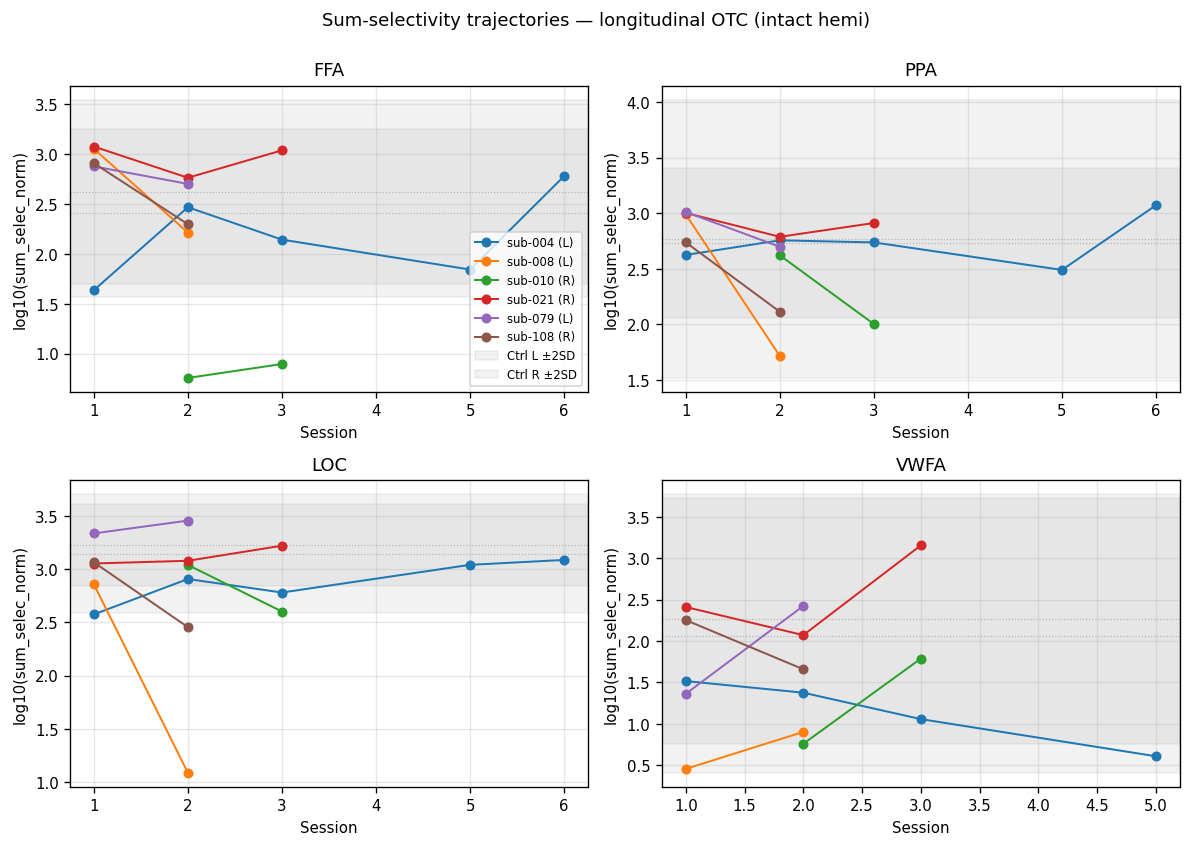

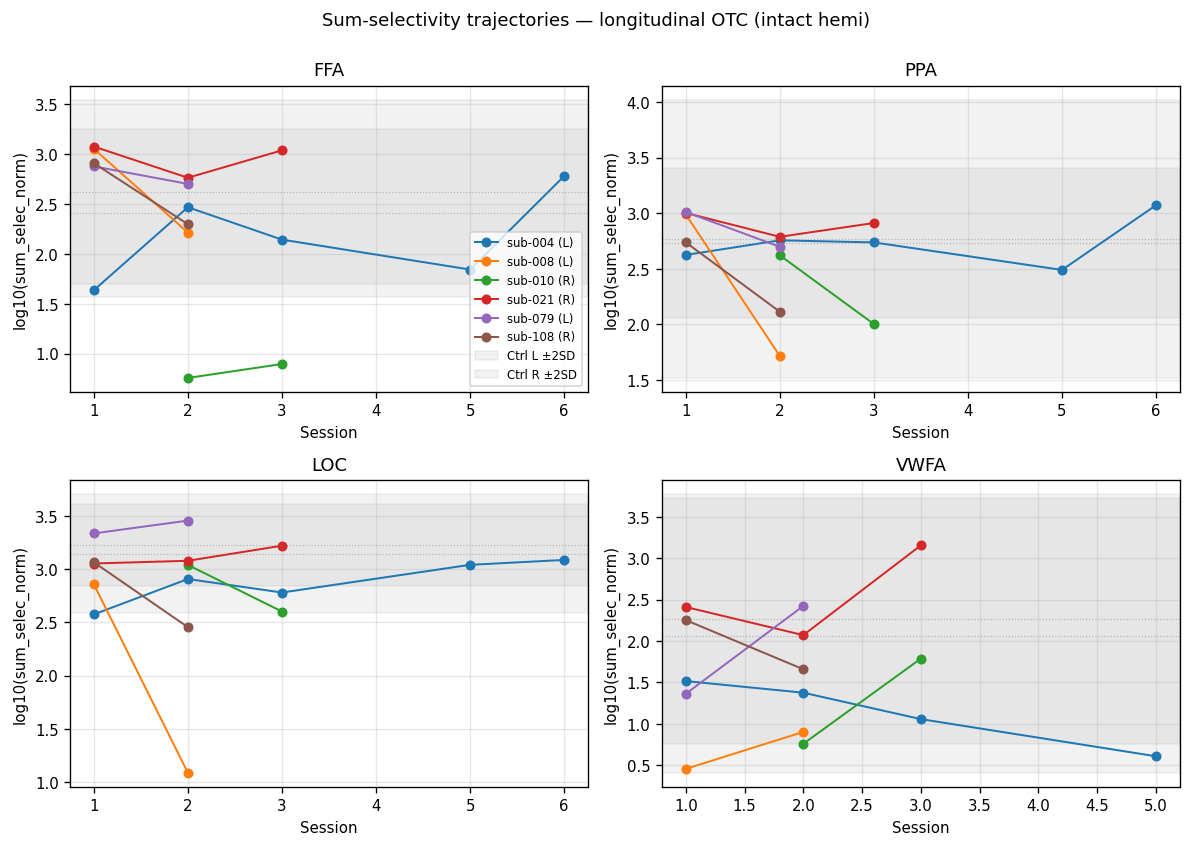

In [8]:
# TC pre/post (intact RH)
if TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('TC pre/post — Sum-selectivity log10 (intact RH)')
    print('=' * 72)
    print(f'{"Parcel":<12} {"Pre":>10} {"Post":>10} {"Δ":>8} '
          f'{"Ctrl M":>8} {"p_pre":>8} {"p_post":>8}')
    print('-' * 72)
    for parcel in PRIMARY_PARCELS:
        tc = sumsel_df[(sumsel_df['subject_id']==TC_SUB) & (sumsel_df['parcel']==parcel) &
                       (sumsel_df['hemi']=='r')]
        pre  = tc[tc['session']==TC_PRE_SES]['log10_sumsel']
        post = tc[tc['session']==TC_POST_SES]['log10_sumsel']
        if pre.empty or post.empty:
            continue
        ctrl = sumsel_df[(sumsel_df['group']=='control') & (sumsel_df['parcel']==parcel) &
                         (sumsel_df['hemi']=='r')]
        ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
        ctrl_v = ctrl[ctrl['session']==ctrl['fs']]['log10_sumsel'].values
        _,_,p_pre,_  = crawford_t(pre.iloc[0],  ctrl_v)
        _,_,p_post,_ = crawford_t(post.iloc[0], ctrl_v)
        print(f'{parcel:<12} {pre.iloc[0]:>10.3f} {post.iloc[0]:>10.3f} '
              f'{post.iloc[0]-pre.iloc[0]:>+8.3f} {np.mean(ctrl_v):>8.3f} '
              f'{p_pre:>8.3f} {p_post:>8.3f}')

plot_trajectories(sumsel_df, 'log10_sumsel',
                  'log10(sum_selec_norm)',
                  'Sum-selectivity trajectories — longitudinal OTC (intact hemi)',
                  'M2_sumsel_trajectories.png')

## Measure 3: Distinctiveness (Liu Fisher-z)

Lower Fisher-z = preferred category response is more distinct from non-preferred. Cross-sectional finding (with caveats): rVWFA RH-intact distinctiveness reduced (Δ = +0.34, raw p = .049, fails BH-FDR).

**Hypothesis:** post-resection distinctiveness drifts toward less distinct (higher Fisher-z) in primary parcels of the intact hemisphere.

Distinctiveness rows: 581

TC pre/post — Distinctiveness (Fisher-z, intact RH)
Parcel              Pre       Post        Δ   Ctrl M    p_pre   p_post
------------------------------------------------------------------------
face_FFA          1.252      1.270   +0.018    0.548    0.070    0.064
house_PPA         0.886      0.640   -0.246    0.495    0.644    0.864
object_LOC        1.569      1.474   -0.094    1.232    0.515    0.638
word_VWFA         0.906      1.148   +0.242    0.365    0.312    0.147


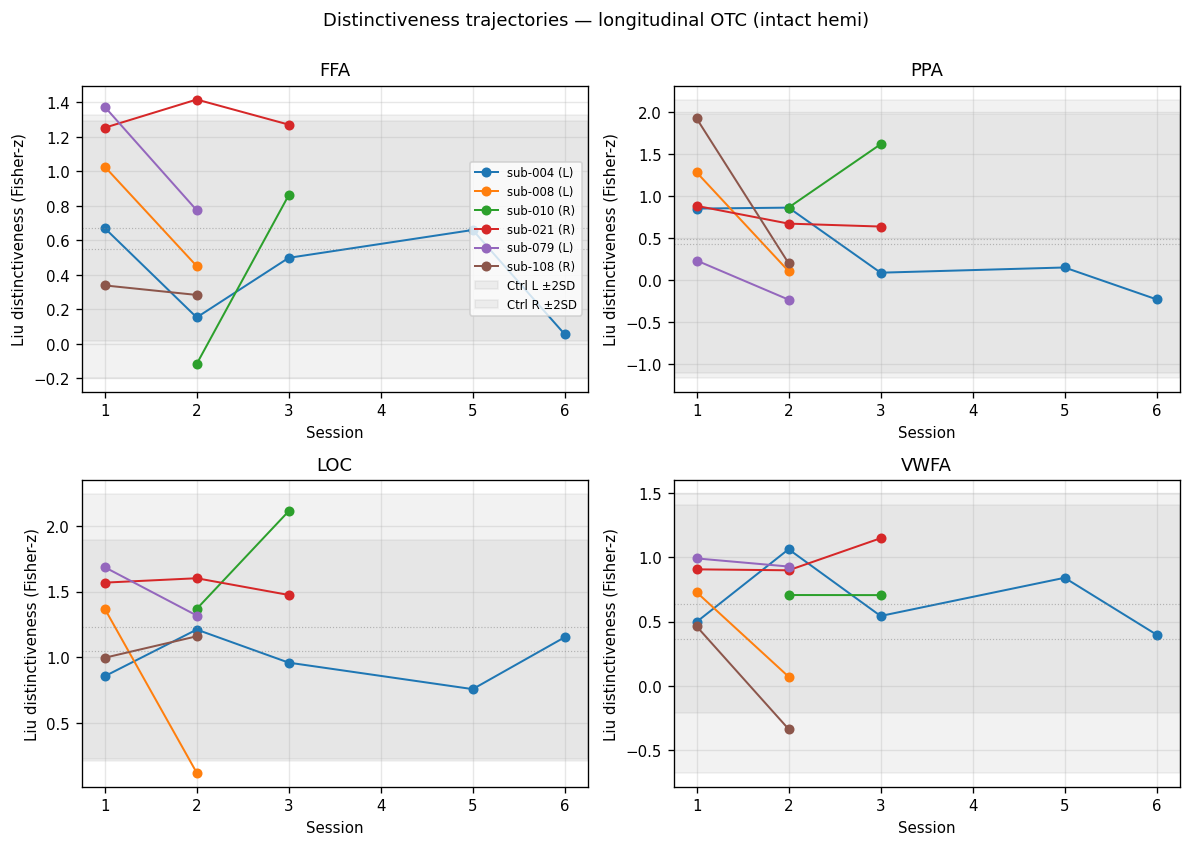

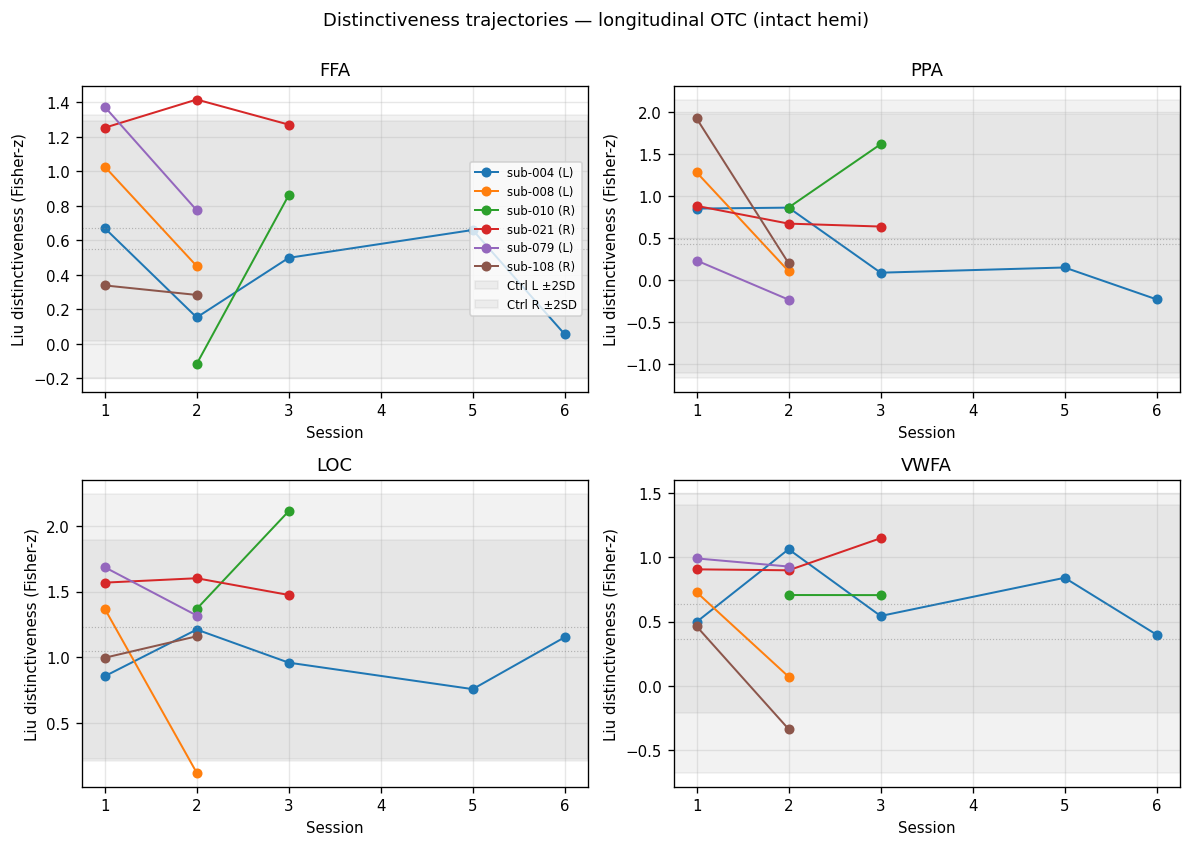

In [9]:
dist_rows = []
for _, r in peak_u.iterrows():
    v = r['liu_distinctiveness']
    if pd.notna(v) and r['category'] in PRIMARY_PARCELS:
        dist_rows.append({
            'subject_id': r['subject_id'], 'session': r['session'],
            'group': r['group'], 'intact_hemi': r.get('intact_hemi', ''),
            'parcel': r['category'], 'hemi': r['hemi'], 'fisher_z': float(v),
        })
distinct_df = pd.DataFrame(dist_rows)
print(f'Distinctiveness rows: {len(distinct_df):,}')

# TC pre/post
if TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('\nTC pre/post — Distinctiveness (Fisher-z, intact RH)')
    print('=' * 72)
    print(f'{"Parcel":<12} {"Pre":>10} {"Post":>10} {"Δ":>8} '
          f'{"Ctrl M":>8} {"p_pre":>8} {"p_post":>8}')
    print('-' * 72)
    for parcel in PRIMARY_PARCELS:
        tc = distinct_df[(distinct_df['subject_id']==TC_SUB) & (distinct_df['parcel']==parcel) &
                         (distinct_df['hemi']=='r')]
        pre  = tc[tc['session']==TC_PRE_SES]['fisher_z']
        post = tc[tc['session']==TC_POST_SES]['fisher_z']
        if pre.empty or post.empty:
            continue
        ctrl = distinct_df[(distinct_df['group']=='control') & (distinct_df['parcel']==parcel) &
                           (distinct_df['hemi']=='r')]
        ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
        ctrl_v = ctrl[ctrl['session']==ctrl['fs']]['fisher_z'].values
        _,_,p_pre,_  = crawford_t(pre.iloc[0],  ctrl_v)
        _,_,p_post,_ = crawford_t(post.iloc[0], ctrl_v)
        print(f'{parcel:<12} {pre.iloc[0]:>10.3f} {post.iloc[0]:>10.3f} '
              f'{post.iloc[0]-pre.iloc[0]:>+8.3f} {np.mean(ctrl_v):>8.3f} '
              f'{p_pre:>8.3f} {p_post:>8.3f}')

plot_trajectories(distinct_df, 'fisher_z',
                  'Liu distinctiveness (Fisher-z)',
                  'Distinctiveness trajectories — longitudinal OTC (intact hemi)',
                  'M3_distinctiveness_trajectories.png')

## Measure 4A: TFCE persistence

Per (sub × ses × cluster), three summary stats extracted from the cluster's own category-vs-others zstat (cope 6/7/8/9):
- `mean_z` — selectivity strength
- `sum_z` — territory loss/gain proxy
- `n_voxels_above` — count at z > 2.326

Clusters: object_L, house_R, word_R, face_L (cross-sectional TFCE survivors, corrp > 0.95).

**Input CSV:** `longitudinal/tfce/tfce_persistence.csv` (from `longitudinal_tfce_trajectories.py`).

In [10]:
PERSIST_CSV = TFCE_LONG_DIR / 'tfce_persistence.csv'

if not PERSIST_CSV.exists():
    print(f'NOT YET AVAILABLE: {PERSIST_CSV}')
    print('Run: python longitudinal_tfce_trajectories.py')
    persist_df = None
else:
    persist_df = pd.read_csv(PERSIST_CSV)
    print(f'Loaded {len(persist_df):,} rows from {PERSIST_CSV.name}')
    print(persist_df.head())

Loaded 128 rows from tfce_persistence.csv
  subject_id  session code group intact_hemi   cluster    mean_z        sum_z  \
0    sub-004        1   UD   OTC        left  object_L -0.910809  -244.096874   
1    sub-004        1   UD   OTC        left   house_R  1.410869   884.614675   
2    sub-004        1   UD   OTC        left    word_R -1.910923 -1303.249434   
3    sub-004        1   UD   OTC        left    face_L  0.189420     3.788399   
4    sub-004        2   UD   OTC        left  object_L -0.393539  -105.468576   

   n_voxels_above  
0               0  
1             145  
2               0  
3               0  
4               0  


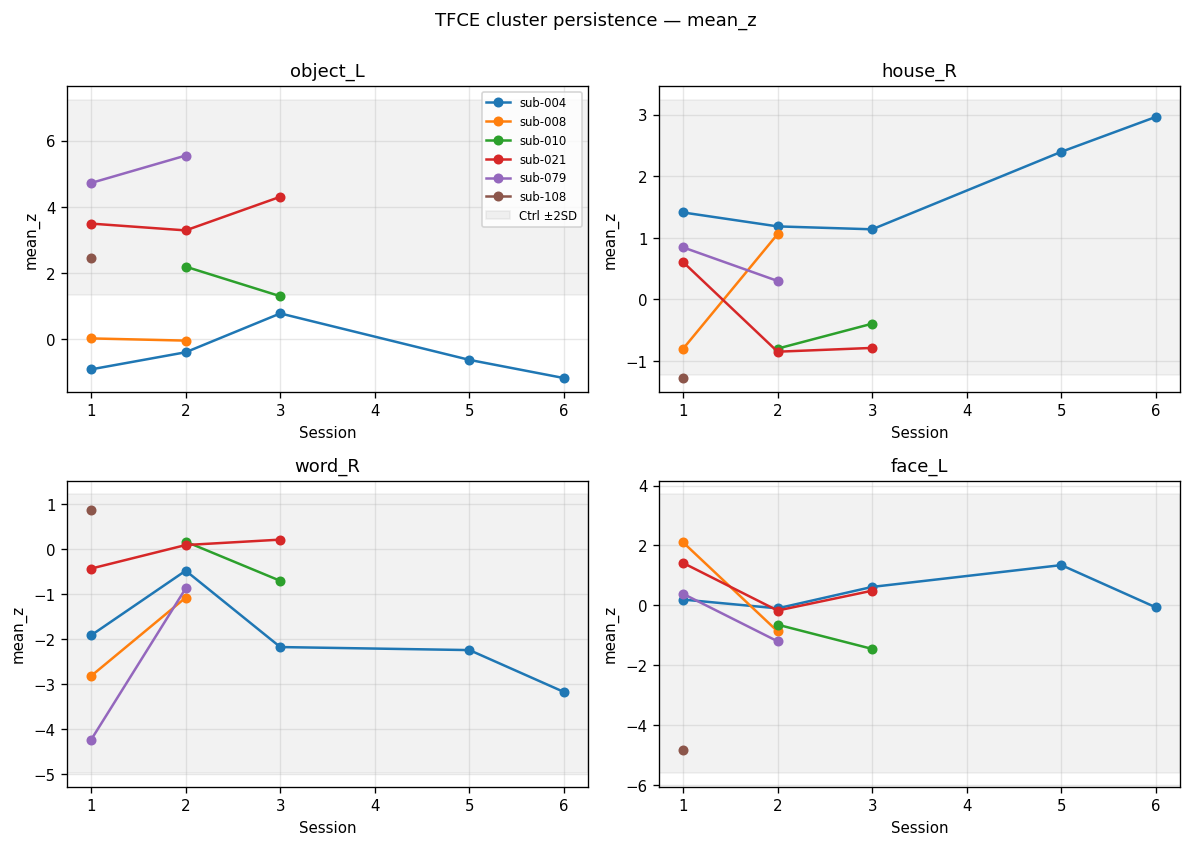

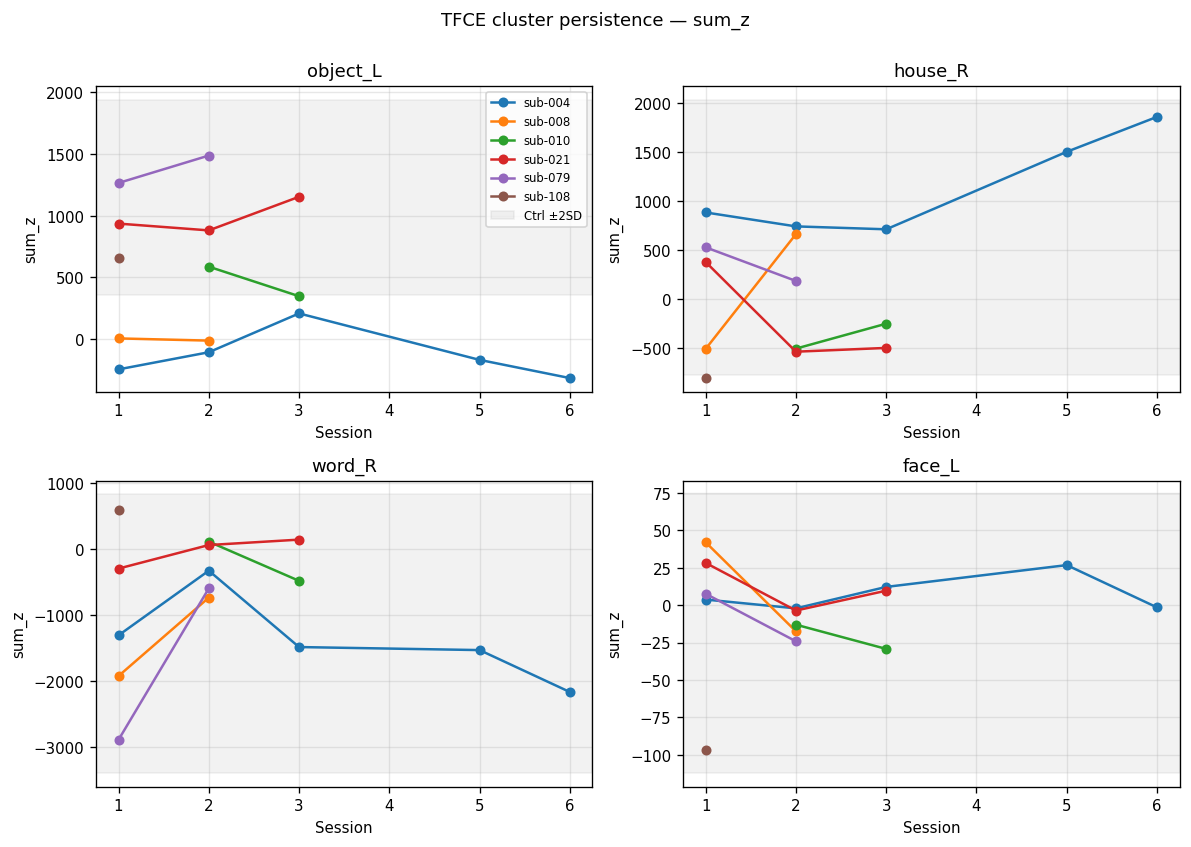

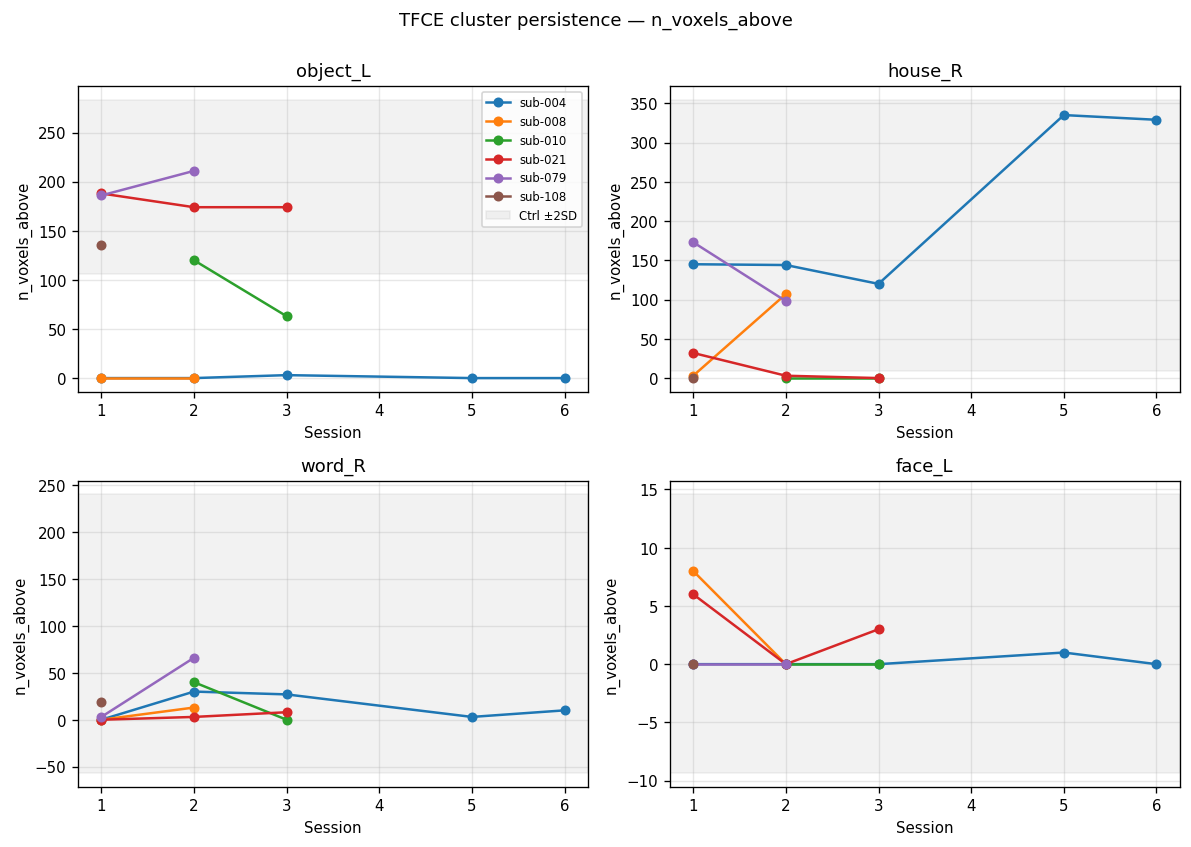

In [11]:
# ── TFCE persistence trajectories ─────────────────────────────────────
# Three subplots per cluster (mean_z, sum_z, n_voxels), longitudinal patients only.
TFCE_CLUSTERS = ['object_L', 'house_R', 'word_R', 'face_L']

if persist_df is not None:
    for stat in ['mean_z', 'sum_z', 'n_voxels_above']:
        fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
        for ax, cluster in zip(axes.flat, TFCE_CLUSTERS):
            for sub in long_otc:
                p = persist_df[(persist_df['subject_id']==sub) &
                               (persist_df['cluster']==cluster)].sort_values('session')
                if p.empty:
                    continue
                ax.plot(p['session'], p[stat], '-o', label=sub, markersize=5)
            # Control reference band
            ctrl = persist_df[(persist_df['group']=='control') & (persist_df['cluster']==cluster)]
            ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
            ctrl_v = ctrl[ctrl['session']==ctrl['fs']][stat].values
            _, _, lo, hi = control_ref_band(ctrl_v)
            if not np.isnan(lo):
                ax.axhspan(lo, hi, alpha=0.10, color='gray', label='Ctrl ±2SD')
            ax.set_title(cluster)
            ax.set_xlabel('Session')
            ax.set_ylabel(stat)
            ax.grid(alpha=0.3)
        axes.flat[0].legend(fontsize=7, loc='best')
        fig.suptitle(f'TFCE cluster persistence — {stat}', y=1.00)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'M4A_tfce_persistence_{stat}.png', dpi=150, bbox_inches='tight')
        plt.show()

In [12]:
# ── TC pre/post for TFCE persistence ──────────────────────────────────
# TC's intact hemisphere is right → meaningful clusters are house_R and word_R.
if persist_df is not None and TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('TC pre/post — TFCE persistence (RH clusters only)')
    print('=' * 80)
    for stat in ['mean_z', 'sum_z', 'n_voxels_above']:
        print(f'\n[{stat}]')
        print(f'{"Cluster":<10} {"Pre":>10} {"Post":>10} {"Δ":>10} '
              f'{"Ctrl M":>10} {"p_pre":>8} {"p_post":>8}')
        print('-' * 80)
        for cluster in ['house_R', 'word_R']:
            tc = persist_df[(persist_df['subject_id']==TC_SUB) & (persist_df['cluster']==cluster)]
            pre  = tc[tc['session']==TC_PRE_SES][stat]
            post = tc[tc['session']==TC_POST_SES][stat]
            if pre.empty or post.empty:
                continue
            ctrl = persist_df[(persist_df['group']=='control') & (persist_df['cluster']==cluster)]
            ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
            ctrl_v = ctrl[ctrl['session']==ctrl['fs']][stat].values
            _,_,p_pre,_  = crawford_t(pre.iloc[0],  ctrl_v)
            _,_,p_post,_ = crawford_t(post.iloc[0], ctrl_v)
            print(f'{cluster:<10} {pre.iloc[0]:>10.3f} {post.iloc[0]:>10.3f} '
                  f'{post.iloc[0]-pre.iloc[0]:>+10.3f} {np.mean(ctrl_v):>10.3f} '
                  f'{p_pre:>8.3f} {p_post:>8.3f}')

TC pre/post — TFCE persistence (RH clusters only)

[mean_z]
Cluster           Pre       Post          Δ     Ctrl M    p_pre   p_post
--------------------------------------------------------------------------------
house_R         0.606     -0.790     -1.396      1.002    0.748    0.175
word_R         -0.429      0.214     +0.643     -1.873    0.408    0.244

[sum_z]
Cluster           Pre       Post          Δ     Ctrl M    p_pre   p_post
--------------------------------------------------------------------------------
house_R       379.876   -495.175   -875.051    628.274    0.748    0.175
word_R       -292.733    145.744   +438.477  -1277.185    0.408    0.244

[n_voxels_above]
Cluster           Pre       Post          Δ     Ctrl M    p_pre   p_post
--------------------------------------------------------------------------------
house_R        32.000      0.000    -32.000    182.000    0.145    0.087
word_R          0.000      8.000     +8.000     91.750    0.281    0.322


## Measure 4B: TFCE preference shifts (Liu McNemar-style)

Per (subject × session-pair × cluster): voxel-wise WTA category at session A vs session B. Voxels enter only if peak z > 2.326 at BOTH sessions. 4×4 transition counts; McNemar χ² tests asymmetry of off-diagonal pairs (e.g., is object→word > word→object within the word_R cluster?).

**Input CSV:** `longitudinal/tfce/tfce_transitions.csv`.

In [13]:
TRANS_CSV = TFCE_LONG_DIR / 'tfce_transitions.csv'

if not TRANS_CSV.exists():
    print(f'NOT YET AVAILABLE: {TRANS_CSV}')
    print('Run: python longitudinal_tfce_trajectories.py')
    trans_df = None
else:
    trans_df = pd.read_csv(TRANS_CSV)
    print(f'Loaded {len(trans_df):,} rows')
    print(trans_df.head())

Loaded 564 rows
  subject_id  ses_a  ses_b code group intact_hemi  cluster from_cat  to_cat  \
0    sub-004      1      2   UD   OTC        left  house_R    house   house   
1    sub-004      1      2   UD   OTC        left  house_R    house  object   
2    sub-004      1      2   UD   OTC        left  house_R    house    word   
3    sub-004      1      2   UD   OTC        left  house_R   object    face   
4    sub-004      1      2   UD   OTC        left  house_R   object   house   

   count  
0     86  
1      2  
2      6  
3      2  
4     14  


In [14]:
# ── McNemar-style asymmetry test per (sub, cluster, session-pair) ─────
CATEGORIES = ['face', 'house', 'object', 'word']

def mcnemar_exact(b, c):
    """Exact binomial McNemar test on counts b and c (off-diagonal).
    Returns (stat, p). Uses two-sided binomial."""
    n = b + c
    if n == 0:
        return np.nan, np.nan
    p = stats.binomtest(min(b, c), n=n, p=0.5).pvalue
    stat = (b - c)**2 / n if n > 0 else np.nan
    return stat, p

def transition_matrix(trans_df, sub, cluster, ses_a, ses_b):
    """Return 4x4 matrix [from_cat × to_cat] of counts."""
    sub_df = trans_df[(trans_df['subject_id']==sub) & (trans_df['cluster']==cluster) &
                      (trans_df['ses_a']==ses_a)  & (trans_df['ses_b']==ses_b)]
    M = np.zeros((4, 4), dtype=int)
    for _, r in sub_df.iterrows():
        i = CATEGORIES.index(r['from_cat'])
        j = CATEGORIES.index(r['to_cat'])
        M[i, j] = r['count']
    return M

def mcnemar_summary(M, label='M'):
    print(f'\n{label}: total voxels = {M.sum()}')
    print(f'  Stable: {np.diag(M).sum()} ({100*np.diag(M).sum()/max(M.sum(),1):.1f}%)')
    print(f'  Asymmetric pair tests (off-diagonal):')
    print(f'  {"from→to":<18} {"b (a→b)":>8} {"c (b→a)":>8} {"χ²":>8} {"p":>8}')
    for i in range(4):
        for j in range(i+1, 4):
            b = M[i, j]; c = M[j, i]
            if b + c < 5:
                continue
            stat, p = mcnemar_exact(b, c)
            sig = '*' if p < .05 else ''
            print(f'  {CATEGORIES[i]:>6}→{CATEGORIES[j]:<10} {b:>8d} {c:>8d} '
                  f'{stat:>8.2f} {p:>8.3f} {sig}')

In [15]:
# ── TC pre/post transitions, intact-hemi clusters ─────────────────────
if trans_df is not None and TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    for cluster in ['house_R', 'word_R']:
        print(f'\n{"="*72}')
        print(f'TC {cluster}: ses-{TC_PRE_SES:02d} → ses-{TC_POST_SES:02d}')
        print(f'{"="*72}')
        M = transition_matrix(trans_df, TC_SUB, cluster, TC_PRE_SES, TC_POST_SES)
        print('Transition matrix (rows=pre, cols=post):')
        print(pd.DataFrame(M, index=CATEGORIES, columns=CATEGORIES))
        mcnemar_summary(M, f'TC/{cluster}')


TC house_R: ses-01 → ses-03
Transition matrix (rows=pre, cols=post):
        face  house  object  word
face       0      0       0     0
house      6      0       0     0
object     1      0       0     0
word       0      0       0     0

TC/house_R: total voxels = 7
  Stable: 0 (0.0%)
  Asymmetric pair tests (off-diagonal):
  from→to             b (a→b)  c (b→a)       χ²        p
    face→house             0        6     6.00    0.031 *

TC word_R: ses-01 → ses-03
Transition matrix (rows=pre, cols=post):
        face  house  object  word
face       2      0       0     1
house      0      6       5     0
object     0      2      39     0
word       0      0       0     0

TC/word_R: total voxels = 55
  Stable: 47 (85.5%)
  Asymmetric pair tests (off-diagonal):
  from→to             b (a→b)  c (b→a)       χ²        p
   house→object            5        2     1.29    0.453 


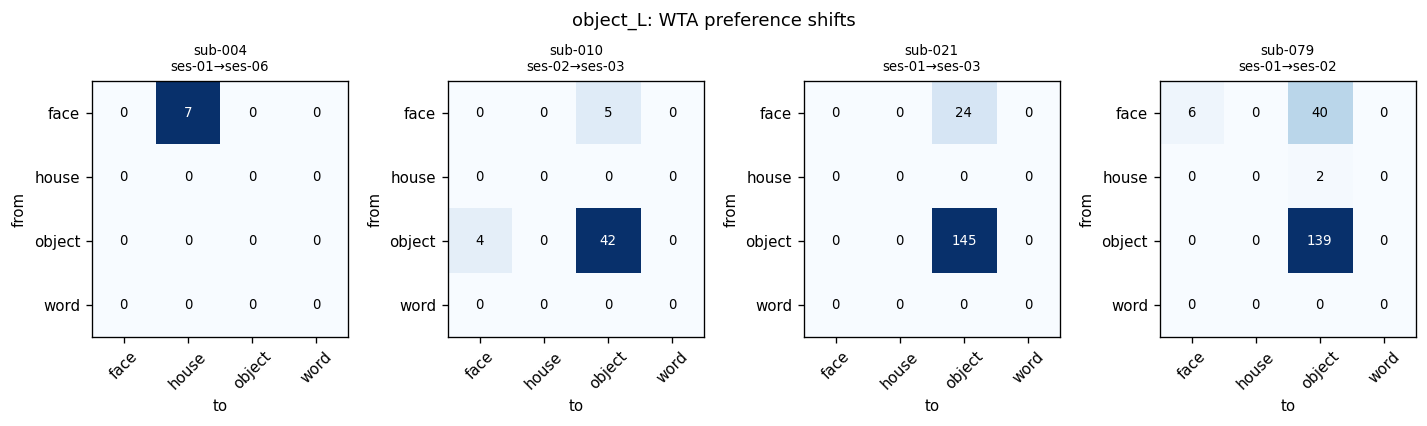

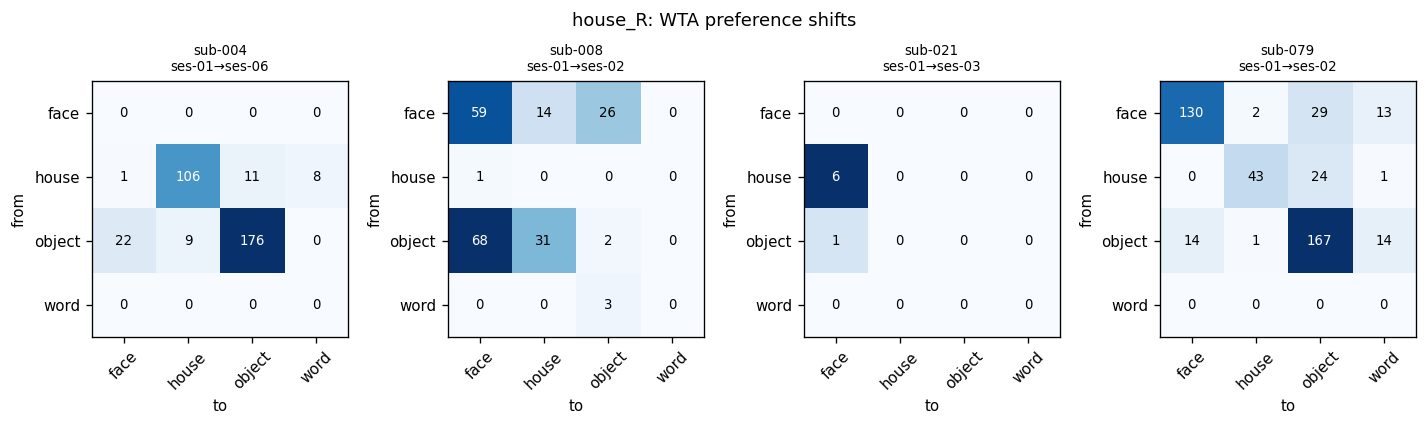

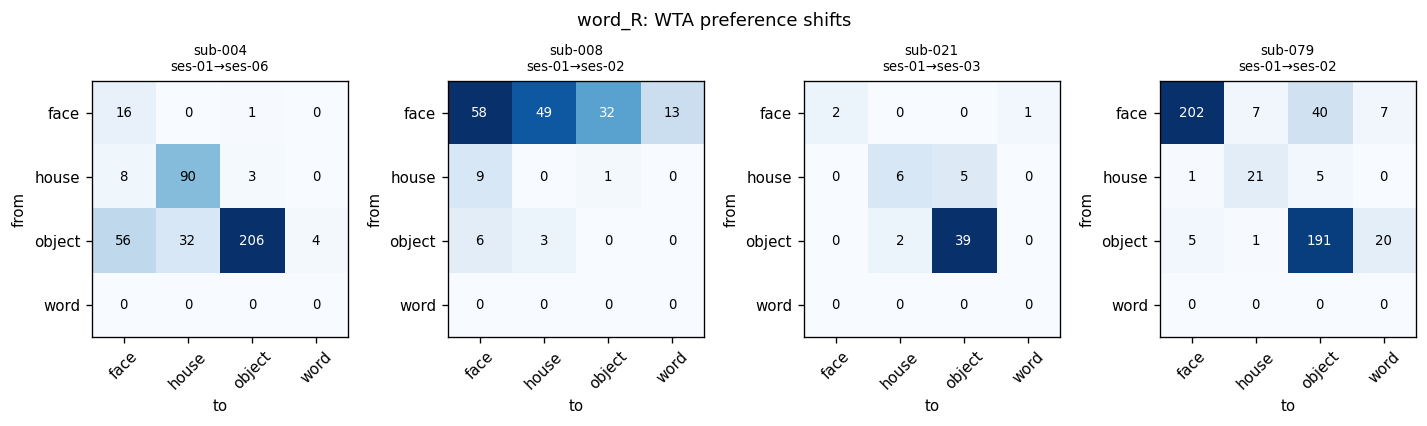

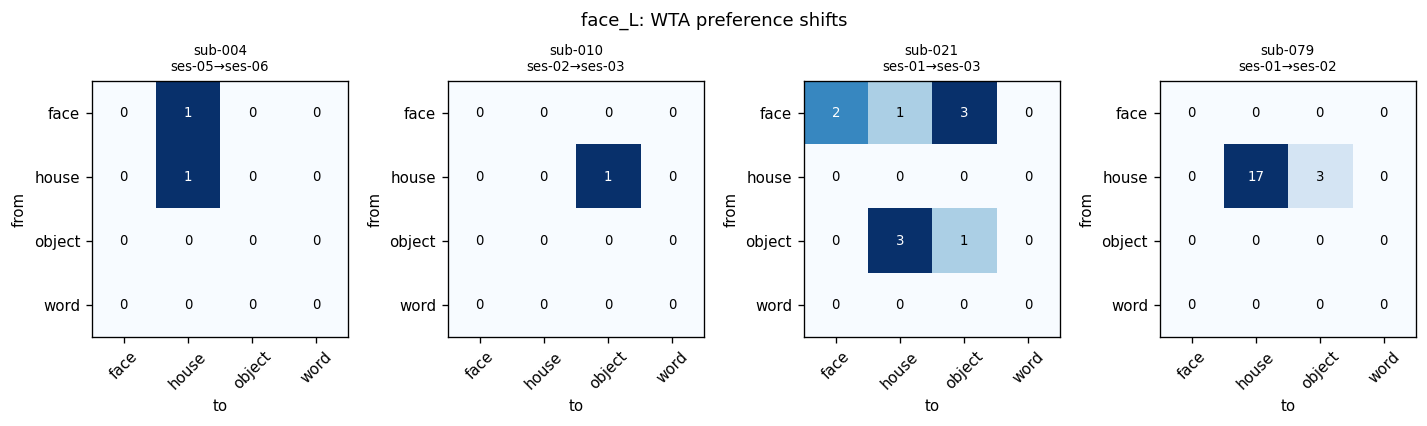

In [16]:
# ── Transition heatmaps for all longitudinal patients ─────────────────
# One figure per cluster, subplots = patients × earliest-vs-latest session pair.
if trans_df is not None:
    for cluster in TFCE_CLUSTERS:
        rel_subs = []
        for sub in long_otc:
            sub_p = trans_df[(trans_df['subject_id']==sub) & (trans_df['cluster']==cluster)]
            if sub_p.empty:
                continue
            # Use earliest available ses_a and latest ses_b for that subject
            ses_a = sub_p['ses_a'].min()
            ses_b = sub_p[sub_p['ses_a']==ses_a]['ses_b'].max()
            rel_subs.append((sub, ses_a, ses_b))
        if not rel_subs:
            continue
        n = len(rel_subs)
        fig, axes = plt.subplots(1, n, figsize=(3*n, 3.2), squeeze=False)
        for ax, (sub, sa, sb) in zip(axes[0], rel_subs):
            M = transition_matrix(trans_df, sub, cluster, sa, sb)
            im = ax.imshow(M, cmap='Blues')
            ax.set_xticks(range(4)); ax.set_yticks(range(4))
            ax.set_xticklabels(CATEGORIES, rotation=45)
            ax.set_yticklabels(CATEGORIES)
            for i in range(4):
                for j in range(4):
                    ax.text(j, i, str(M[i,j]), ha='center', va='center',
                            color='white' if M[i,j]>M.max()/2 else 'black', fontsize=8)
            ax.set_title(f'{sub}\nses-{sa:02d}→ses-{sb:02d}', fontsize=8)
            ax.set_xlabel('to')
            ax.set_ylabel('from')
        fig.suptitle(f'{cluster}: WTA preference shifts', y=1.02)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'M4B_transitions_{cluster}.png', dpi=150, bbox_inches='tight')
        plt.show()

---

## Notes for write-up

- **Cross-sectional vs longitudinal framing:** CS = state at one timepoint; longitudinal = trajectory over time. Headline question for this section: "Do CS findings persist within-subject over time, and does TC pre/post show change in the predicted direction?"
- **n=1 for TC pre/post:** report directional shifts + Crawford-H p-values; flag as case study, not group inference.
- **Other 5 patients (post-only):** test for stability, not pre-post change.
- **TC pre-surgical RH atypical (per Liu 2025):** baseline already contains pathological reorganization; soften causal claims.
- **Sub-108 ses-02:** needs `13_register_zstats_mni.py` for that single session before it enters analyses.

In [17]:
# Per-patient trajectory dump (post-only patients)
for sub in long_otc:
    if sub == TC_SUB:
        continue
    hemi = patient_intact_hemi(sub)
    print(f'\n{sub} (intact={hemi.upper()})')
    for measure_df, col, label in [(dist_df, 'distance', 'peak_dist'),
                                    (sumsel_df, 'log10_sumsel', 'sumsel'),
                                    (distinct_df, 'fisher_z', 'distinct')]:
        p = measure_df[(measure_df['subject_id']==sub) & (measure_df['hemi']==hemi)]
        for parcel in PRIMARY_PARCELS:
            vals = p[p['parcel']==parcel].sort_values('session')
            if vals.empty: continue
            traj = ', '.join(f'ses{int(s)}={v:.2f}' for s,v in
                             zip(vals['session'], vals[col]))
            print(f'  {label:9s} {parcel:11s}: {traj}')

if persist_df is not None:
    print('\n\nTFCE persistence (post-only patients):')
    for sub in long_otc:
        if sub == TC_SUB:
            continue
        print(f'\n{sub}')
        for cluster in TFCE_CLUSTERS:
            p = persist_df[(persist_df['subject_id']==sub) &
                           (persist_df['cluster']==cluster)].sort_values('session')
            if p.empty: continue
            traj = ', '.join(f'ses{int(s)}: mz={mz:.2f}, nv={nv}'
                             for s,mz,nv in zip(p['session'], p['mean_z'], p['n_voxels_above']))
            print(f'  {cluster:9s}: {traj}')


sub-004 (intact=L)
  peak_dist face_FFA   : ses1=12.12, ses2=9.16, ses3=12.10, ses5=15.55, ses6=8.97
  peak_dist house_PPA  : ses1=23.07, ses2=25.39, ses3=15.00, ses5=14.57, ses6=19.55
  peak_dist object_LOC : ses1=12.44, ses2=8.84, ses3=11.75, ses5=5.45, ses6=7.48
  peak_dist word_VWFA  : ses1=6.55, ses2=11.05, ses3=28.08, ses5=18.73, ses6=28.24
  sumsel    face_FFA   : ses1=1.64, ses2=2.47, ses3=2.14, ses5=1.84, ses6=2.78
  sumsel    house_PPA  : ses1=2.62, ses2=2.76, ses3=2.74, ses5=2.49, ses6=3.07
  sumsel    object_LOC : ses1=2.57, ses2=2.91, ses3=2.78, ses5=3.04, ses6=3.09
  sumsel    word_VWFA  : ses1=1.52, ses2=1.38, ses3=1.06, ses5=0.61
  distinct  face_FFA   : ses1=0.67, ses2=0.15, ses3=0.50, ses5=0.66, ses6=0.06
  distinct  house_PPA  : ses1=0.85, ses2=0.87, ses3=0.09, ses5=0.15, ses6=-0.23
  distinct  object_LOC : ses1=0.85, ses2=1.21, ses3=0.96, ses5=0.76, ses6=1.15
  distinct  word_VWFA  : ses1=0.50, ses2=1.06, ses3=0.54, ses5=0.84, ses6=0.40

sub-008 (intact=L)
  peak_d


Patient    Hemi Ses   Yrs PO    Age Cluster      mean_z  n_vox>thr
sub-004    L    1       1.81   7.81 face_L         0.19          0
sub-004    L    1       1.81   7.81 object_L      -0.91          0
sub-004    L    2       2.37   8.37 face_L        -0.10          0
sub-004    L    2       2.37   8.37 object_L      -0.39          1
sub-004    L    3       2.83   8.83 face_L         0.61          0
sub-004    L    3       2.83   8.83 object_L       0.78          8
sub-004    L    5       4.83  10.83 face_L         1.34          6
sub-004    L    5       4.83  10.83 object_L      -0.62          0
sub-004    L    6       7.08  13.08 face_L        -0.07          0
sub-004    L    6       7.08  13.08 object_L      -1.17          0
----------------------------------------------------------------------------------------
sub-008    L    1       6.78  14.78 face_L         2.10         14
sub-008    L    1       6.78  14.78 object_L       0.02          0
sub-008    L    2       9.90  17.90 fac

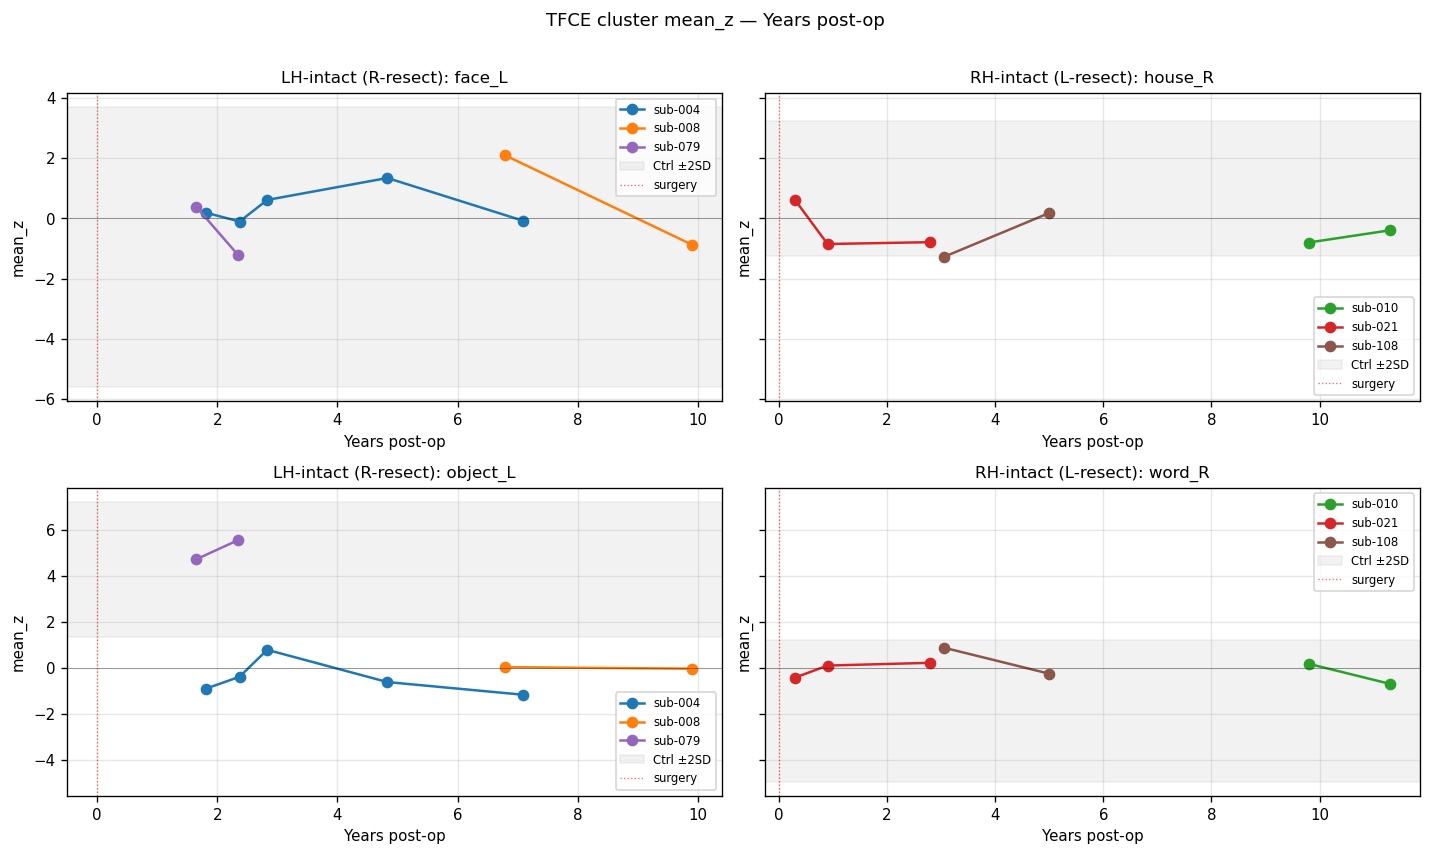

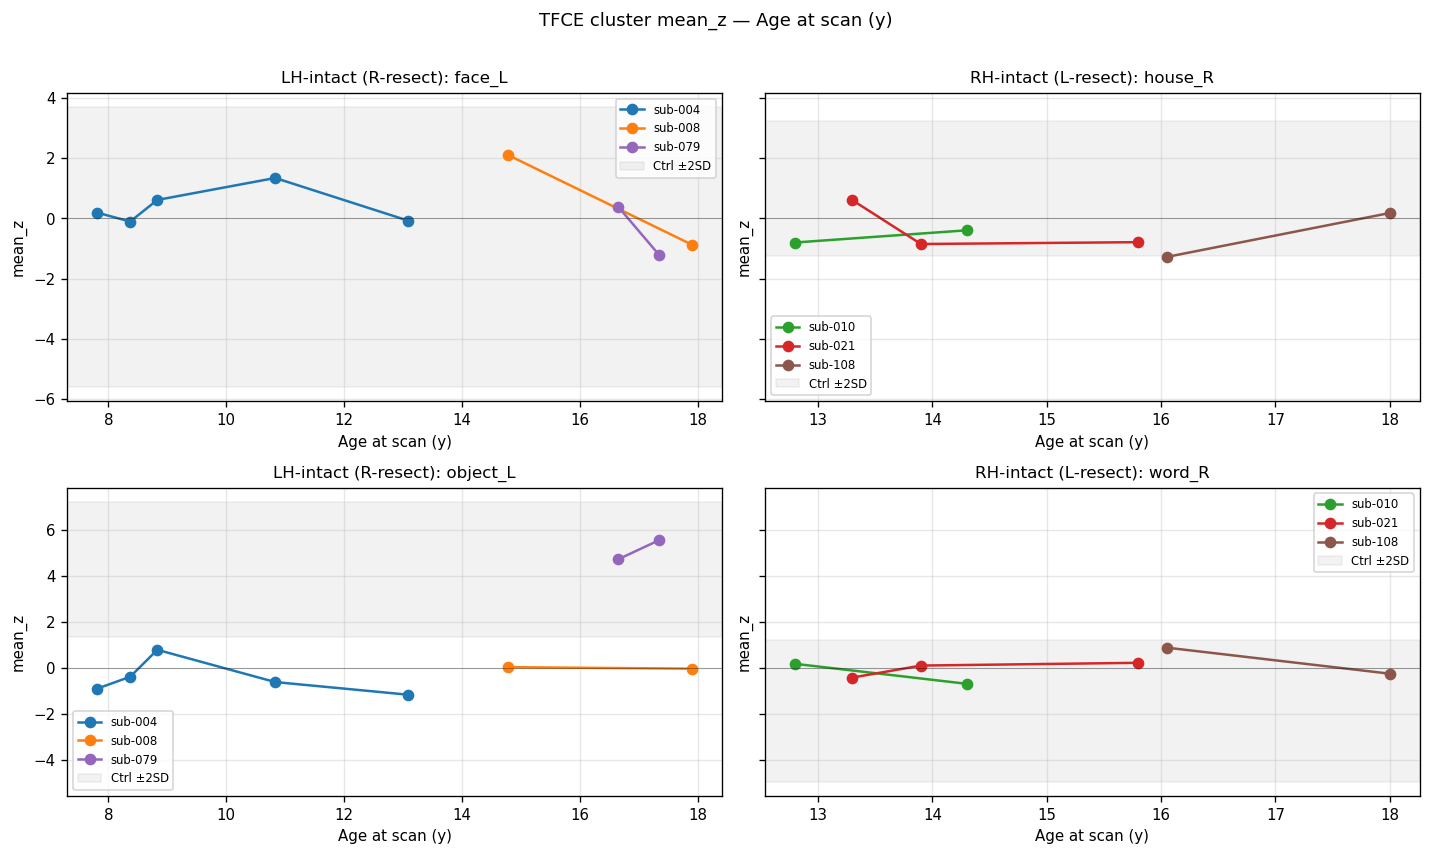

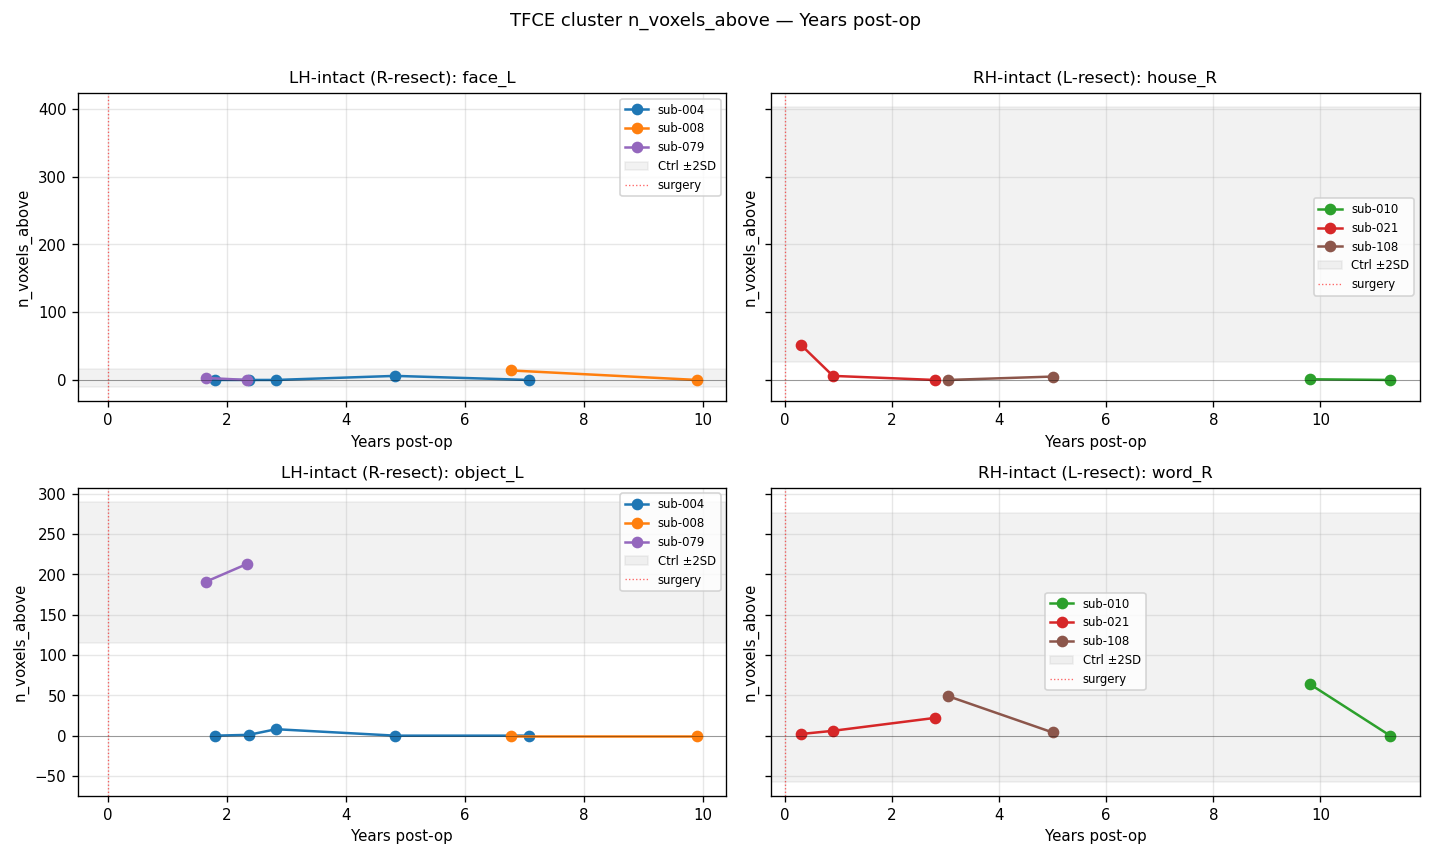

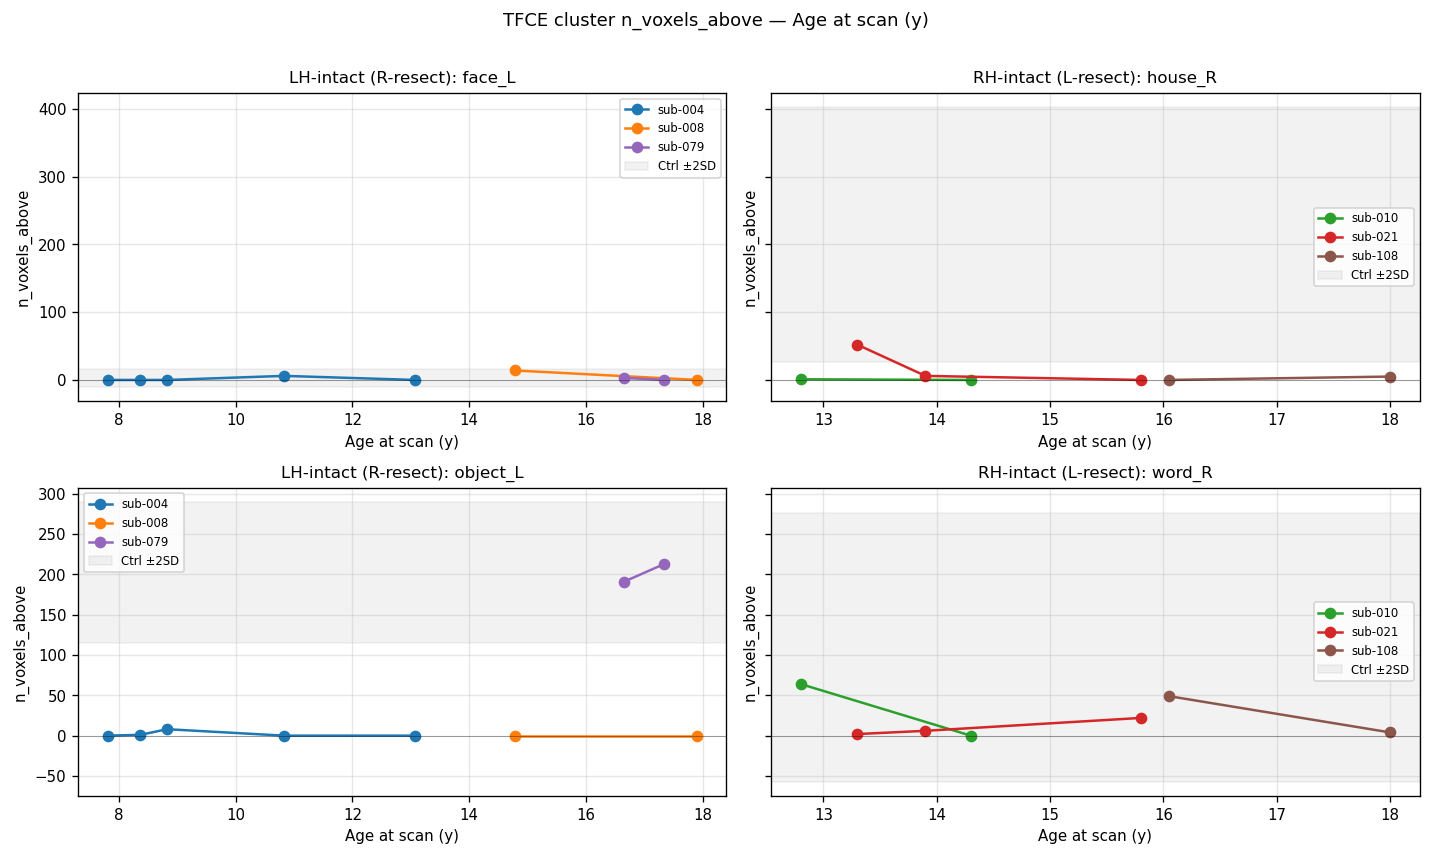


Patient    Hemi Ses   Yrs PO    Age Cluster      mean_z  n_vox>thr
sub-004    L    1       1.81   7.81 face_L         0.19          0
sub-004    L    1       1.81   7.81 object_L      -0.91          0
sub-004    L    2       2.37   8.37 face_L        -0.10          0
sub-004    L    2       2.37   8.37 object_L      -0.39          1
sub-004    L    3       2.83   8.83 face_L         0.61          0
sub-004    L    3       2.83   8.83 object_L       0.78          8
sub-004    L    5       4.83  10.83 face_L         1.34          6
sub-004    L    5       4.83  10.83 object_L      -0.62          0
sub-004    L    6       7.08  13.08 face_L        -0.07          0
sub-004    L    6       7.08  13.08 object_L      -1.17          0
----------------------------------------------------------------------------------------
sub-008    L    1       6.78  14.78 face_L         2.10         14
sub-008    L    1       6.78  14.78 object_L       0.02          0
sub-008    L    2       9.90  17.90 fac

In [ ]:
persist_df = pd.read_csv(TFCE_LONG_DIR / 'tfce_persistence_thr196.csv')

# ── Post-op + age lookups (hardcoded from sub_info4_30.csv) ────────────
postop_lookup = {
    ('sub-004', 1): 1.81, ('sub-004', 2): 2.37, ('sub-004', 3): 2.83,
    ('sub-004', 5): 4.83, ('sub-004', 6): 7.08,
    ('sub-008', 1): 6.78, ('sub-008', 2): 9.90,
    ('sub-010', 2): 9.80, ('sub-010', 3): 11.30,
    ('sub-021', 1): 0.30, ('sub-021', 2): 0.90, ('sub-021', 3): 2.80,
    ('sub-079', 1): 1.65, ('sub-079', 2): 2.34,
    ('sub-108', 1): 3.05, ('sub-108', 2): 5.00,
}
age_lookup = {
    ('sub-004', 1): 7.81,  ('sub-004', 2): 8.37,  ('sub-004', 3): 8.83,
    ('sub-004', 5): 10.83, ('sub-004', 6): 13.08,
    ('sub-008', 1): 14.78, ('sub-008', 2): 17.90,
    ('sub-010', 2): 12.80, ('sub-010', 3): 14.30,
    ('sub-021', 1): 13.30, ('sub-021', 2): 13.90, ('sub-021', 3): 15.80,
    ('sub-079', 1): 16.65, ('sub-079', 2): 17.34,
    ('sub-108', 1): 16.05, ('sub-108', 2): 18.00,
}

# ── Per-patient colors (stable across LH/RH panels) ────────────────────
PATIENT_COLORS = {
    'sub-004': '#1f77b4',  # blue
    'sub-008': '#ff7f0e',  # orange
    'sub-010': '#2ca02c',  # green
    'sub-021': '#d62728',  # red  (TC)
    'sub-079': '#9467bd',  # purple
    'sub-108': '#8c564b',  # brown
}

# ── Butterfly plot: LH-intact (left) | RH-intact (right) ───────────────
def butterfly_tfce(persist_df, stat, x_lookup, x_label, fname):
    lh_subs = [s for s in long_otc if patient_intact_hemi(s) == 'l']
    rh_subs = [s for s in long_otc if patient_intact_hemi(s) == 'r']
    lh_clusters = ['face_L', 'object_L']   # LH-intact patients' relevant clusters
    rh_clusters = ['house_R', 'word_R']    # RH-intact patients' relevant clusters

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')
    for col, (side_subs, clusters, side_label) in enumerate([
        (lh_subs, lh_clusters, 'LH-intact (R-resect)'),
        (rh_subs, rh_clusters, 'RH-intact (L-resect)'),
    ]):
        for row, cluster in enumerate(clusters):
            ax = axes[row, col]
            for sub in side_subs:
                p = persist_df[(persist_df['subject_id']==sub) &
                               (persist_df['cluster']==cluster)].copy()
                if p.empty:
                    continue
                p['x'] = p['session'].apply(lambda s: x_lookup.get((sub, int(s)), np.nan))
                p = p.dropna(subset=['x']).sort_values('x')
                if p.empty:
                    continue
                ax.plot(p['x'], p[stat], '-o',
                        color=PATIENT_COLORS.get(sub, 'gray'),
                        label=sub, markersize=6, linewidth=1.5)
            # Control reference band (controls have no post-op axis; show as horizontal)
            ctrl = persist_df[(persist_df['group']=='control') &
                              (persist_df['cluster']==cluster)]
            ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
            ctrl_v = ctrl[ctrl['session']==ctrl['fs']][stat].values
            _, _, lo, hi = control_ref_band(ctrl_v)
            if not np.isnan(lo):
                ax.axhspan(lo, hi, alpha=0.10, color='gray', label='Ctrl ±2SD')
            ax.axhline(0, color='k', lw=0.5, alpha=0.4)
            if 'post-op' in x_label.lower():
                ax.axvline(0, color='red', lw=0.8, linestyle=':', alpha=0.6, label='surgery')
            ax.set_title(f'{side_label}: {cluster}', fontsize=10)
            ax.set_xlabel(x_label)
            ax.set_ylabel(stat)
            ax.grid(alpha=0.3)
            ax.legend(fontsize=7, loc='best')
    fig.suptitle(f'TFCE cluster {stat} — {x_label}', y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


# ── Run plots: both x-axes, both stats ─────────────────────────────────
if persist_df is not None:
    for stat in ['mean_z', 'n_voxels_above']:
        butterfly_tfce(persist_df, stat, postop_lookup, 'Years post-op',
                       f'M4A_tfce_{stat}_postop.png')
        butterfly_tfce(persist_df, stat, age_lookup, 'Age at scan (y)',
                       f'M4A_tfce_{stat}_age.png')


# ── Text printout: trajectories sorted by post-op time, one row per session ──
def print_trajectories(persist_df):
    print('\n' + '='*88)
    print(f'{"Patient":<10} {"Hemi":<4} {"Ses":<4} {"Yrs PO":>7} {"Age":>6} '
          f'{"Cluster":<10} {"mean_z":>8} {"n_vox>thr":>10}')
    print('='*88)
    for sub in sorted(long_otc):
        hemi = patient_intact_hemi(sub).upper()
        clusters = ['face_L', 'object_L'] if hemi == 'L' else ['house_R', 'word_R']
        sub_df = persist_df[persist_df['subject_id']==sub]
        sessions = sorted(sub_df['session'].unique())
        for ses in sessions:
            yrs = postop_lookup.get((sub, int(ses)), np.nan)
            age = age_lookup.get((sub, int(ses)), np.nan)
            for cluster in clusters:
                r = sub_df[(sub_df['session']==ses) & (sub_df['cluster']==cluster)]
                if r.empty:
                    continue
                r = r.iloc[0]
                print(f'{sub:<10} {hemi:<4} {ses:<4} '
                      f'{yrs:>7.2f} {age:>6.2f} {cluster:<10} '
                      f'{r["mean_z"]:>8.2f} {int(r["n_voxels_above"]):>10}')
        print('-'*88)

if persist_df is not None:
    print_trajectories(persist_df)

## Cross-sectional takeover test

Across-patient correlation within each TFCE gain cluster. For each gain cluster
(word_R, face_L), extract per-patient mean z for the gain category and each
candidate "donor" category. Test whether higher gain z correlates with lower
donor z across patients — a negative correlation supports a trade-off /
takeover interpretation, even without WTA-level switching.

Restricted to OTC patients in the relevant intact-hemi group (word_R uses
RH-intact, face_L uses LH-intact). One session per patient (first post).

In [32]:
# ── Extract per-patient z within each TFCE cluster, for all 4 categories ──
import nibabel as nib

CAT_COPES = {'face': 6, 'house': 7, 'object': 8, 'word': 9}
CATEGORIES_LIST = ['face', 'house', 'object', 'word']
CORRP_THRESH = 0.95

CLUSTER_DEFS = {
    'object_L': {'category': 'object', 'hemi': 'l', 'tstat': 1},
    'house_R':  {'category': 'house',  'hemi': 'r', 'tstat': 1},
    'word_R':   {'category': 'word',   'hemi': 'r', 'tstat': 2},
    'face_L':   {'category': 'face',   'hemi': 'l', 'tstat': 2},
}

TFCE_DIR = Path(processed_dir) / 'group_results' / 'tfce_votc'

def load_cluster_mask(cluster):
    d = CLUSTER_DEFS[cluster]
    p = TFCE_DIR / f'{d["category"]}_{d["hemi"]}_pt_vs_ctrl' / f'rand_tfce_corrp_tstat{d["tstat"]}.nii.gz'
    return nib.load(str(p)).get_fdata() > CORRP_THRESH

cluster_masks = {c: load_cluster_mask(c) for c in CLUSTER_DEFS}

# Sub_info-derived helpers (uses already-loaded peak_u + info)
EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

def first_post_session(sub):
    """Return zero-padded session string of first post-surgery session, or None."""
    info_sub = info[info['subject_id']==sub].sort_values('session')
    if info_sub.empty:
        return None
    pre = PRE_SURGERY_SESSIONS.get(sub, set())
    for _, r in info_sub.iterrows():
        ses = f'{int(r["session"]):02d}'
        if ses not in pre:
            return ses
    return None

def cluster_z_path(sub, ses, anchor, cope):
    base = (Path(processed_dir) / sub / f'ses-{ses}' / 'derivatives' / 'fsl'
            / 'loc' / 'HighLevel.gfeat' / f'cope{cope}.feat' / 'stats')
    if ses == anchor:
        p = base / 'zstat1_mni.nii.gz'
        return p if p.exists() else None
    p_anchor = base / f'zstat1_ses{anchor}_mni.nii.gz'
    if p_anchor.exists():
        return p_anchor
    p_self = base / 'zstat1_mni.nii.gz'
    return p_self if p_self.exists() else None

# Build per-patient (and control) mean z within each cluster × category
rows = []
all_otc = sorted(peak_u[peak_u['group']=='OTC']['subject_id'].unique())
all_ctrl = sorted(peak_u[peak_u['group']=='control']['subject_id'].unique())

for grp_label, sub_list in [('OTC', all_otc), ('control', all_ctrl)]:
    for sub in sub_list:
        if sub in EXTRA_SKIP:
            continue
        ses = first_post_session(sub)
        if ses is None:
            continue
        info_row = info[(info['subject_id']==sub) & (info['session']==int(ses))]
        if info_row.empty:
            continue
        intact = info_row.iloc[0].get('intact_hemi', 'both')
        # Load all 4 cat zstats for this sub/ses
        vols = {}
        ok = True
        for cat, cope in CAT_COPES.items():
            p = cluster_z_path(sub, ses, ses, cope)  # anchor=first post, so same
            if p is None:
                ok = False
                break
            vols[cat] = nib.load(str(p)).get_fdata()
        if not ok:
            continue
        # For each cluster, mean z per category
        for cluster, mask in cluster_masks.items():
            for cat in CATEGORIES_LIST:
                vals = vols[cat][mask]
                vals = vals[~np.isnan(vals)]
                rows.append({
                    'subject_id': sub, 'session': int(ses), 'group': grp_label,
                    'intact_hemi': intact, 'cluster': cluster, 'category': cat,
                    'mean_z': float(vals.mean()) if vals.size else np.nan,
                })
        print(f'  {sub} ses-{ses} done')

cs_cluster_z = pd.DataFrame(rows)
out_csv = Path(processed_dir) / 'group_results' / 'longitudinal' / 'tfce' / 'cs_cluster_z_all_cats.csv'
cs_cluster_z.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv} ({len(cs_cluster_z):,} rows)')
print(f'Subjects: OTC={cs_cluster_z[cs_cluster_z["group"]=="OTC"]["subject_id"].nunique()}, '
      f'control={cs_cluster_z[cs_cluster_z["group"]=="control"]["subject_id"].nunique()}')

  sub-004 ses-01 done
  sub-005 ses-01 done
  sub-008 ses-01 done
  sub-010 ses-02 done
  sub-021 ses-02 done
  sub-039 ses-01 done
  sub-044 ses-01 done
  sub-066 ses-01 done
  sub-069 ses-01 done
  sub-074 ses-01 done
  sub-075 ses-01 done
  sub-076 ses-01 done
  sub-077 ses-01 done
  sub-078 ses-01 done
  sub-079 ses-01 done
  sub-082 ses-01 done
  sub-089 ses-01 done
  sub-090 ses-01 done
  sub-091 ses-01 done
  sub-092 ses-01 done
  sub-099 ses-01 done
  sub-108 ses-01 done
  sub-001 ses-01 done
  sub-016 ses-01 done
  sub-018 ses-02 done
  sub-022 ses-01 done
  sub-023 ses-01 done
  sub-025 ses-01 done
  sub-026 ses-01 done
  sub-027 ses-02 done
  sub-028 ses-01 done
  sub-029 ses-01 done
  sub-031 ses-01 done
  sub-034 ses-01 done
  sub-035 ses-01 done
  sub-036 ses-01 done
  sub-037 ses-01 done
  sub-038 ses-02 done
  sub-040 ses-01 done
  sub-041 ses-01 done
  sub-043 ses-01 done
  sub-052 ses-01 done
  sub-054 ses-01 done
  sub-057 ses-02 done
  sub-058 ses-01 done
  sub-059 

Cross-subject correlation within each gain cluster (OTC patients only)

RH-intact: word_R cluster  n=11
  vs          Pearson r        p  Spearman r        p
  word~face         0.654    0.029       0.418    0.201 *
  word~house       -0.915    0.000      -0.745    0.008 *
  word~object      -0.928    0.000      -0.873    0.000 *

LH-intact: face_L cluster  n=11
  vs          Pearson r        p  Spearman r        p
  face~house       -0.090    0.793      -0.091    0.790 
  face~object       0.002    0.996      -0.036    0.915 
  face~word        -0.324    0.331      -0.155    0.650 


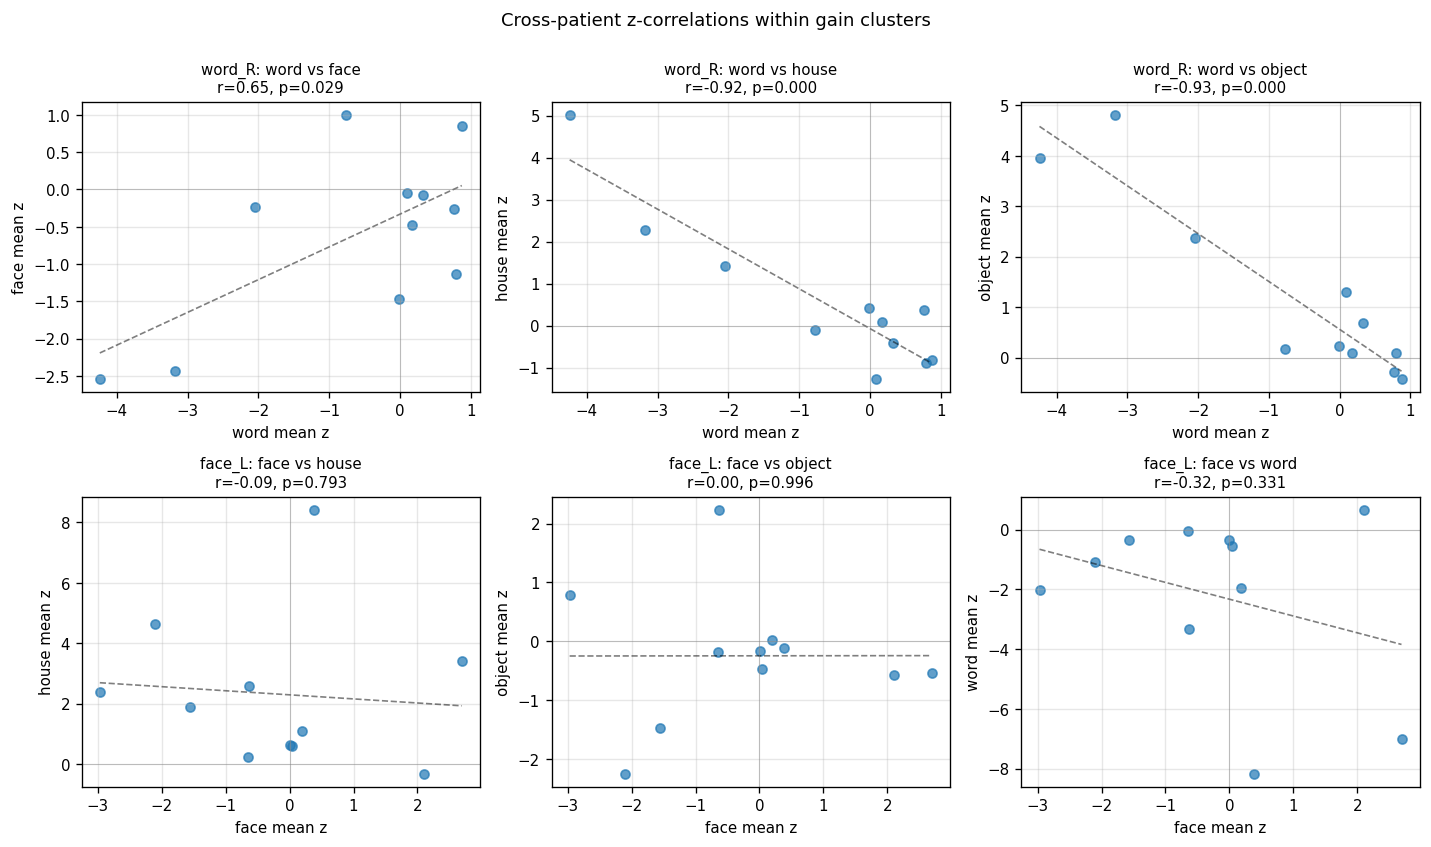

In [33]:
# ── Across-patient correlation: gain category vs candidate donor categories ──
from scipy.stats import pearsonr, spearmanr

GAIN_TESTS = [
    # (cluster, gain_cat, intact_filter, label)
    ('word_R',  'word',  'right', 'RH-intact: word_R cluster'),
    ('face_L',  'face',  'left',  'LH-intact: face_L cluster'),
]

# Wide format: one row per (subject, cluster), columns = each category's mean_z
wide = cs_cluster_z.pivot_table(index=['subject_id','group','intact_hemi','cluster'],
                                 columns='category', values='mean_z').reset_index()

print('Cross-subject correlation within each gain cluster (OTC patients only)')
print('=' * 78)
for cluster, gain_cat, intact, label in GAIN_TESTS:
    sub_df = wide[(wide['cluster']==cluster) & (wide['group']=='OTC') &
                  (wide['intact_hemi']==intact)]
    print(f'\n{label}  n={len(sub_df)}')
    print(f'  {"vs":<10} {"Pearson r":>10} {"p":>8} {"Spearman r":>11} {"p":>8}')
    for other_cat in CATEGORIES_LIST:
        if other_cat == gain_cat:
            continue
        x = sub_df[gain_cat].values
        y = sub_df[other_cat].values
        m = ~(np.isnan(x) | np.isnan(y))
        if m.sum() < 3:
            continue
        r_p, p_p = pearsonr(x[m], y[m])
        r_s, p_s = spearmanr(x[m], y[m])
        sig = '*' if min(p_p, p_s) < .05 else ('†' if min(p_p,p_s) < .10 else '')
        print(f'  {gain_cat}~{other_cat:<7} {r_p:>10.3f} {p_p:>8.3f} '
              f'{r_s:>11.3f} {p_s:>8.3f} {sig}')

# Scatter plots: 2 clusters × candidate donors
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for row, (cluster, gain_cat, intact, label) in enumerate(GAIN_TESTS):
    sub_df = wide[(wide['cluster']==cluster) & (wide['group']=='OTC') &
                  (wide['intact_hemi']==intact)]
    others = [c for c in CATEGORIES_LIST if c != gain_cat]
    for col, other_cat in enumerate(others):
        ax = axes[row, col]
        x = sub_df[gain_cat].values
        y = sub_df[other_cat].values
        m = ~(np.isnan(x) | np.isnan(y))
        ax.scatter(x[m], y[m], s=30, alpha=0.7)
        if m.sum() >= 3:
            r, p = pearsonr(x[m], y[m])
            ax.set_title(f'{cluster}: {gain_cat} vs {other_cat}\nr={r:.2f}, p={p:.3f}', fontsize=9)
            # Trend line
            z = np.polyfit(x[m], y[m], 1)
            xs = np.linspace(x[m].min(), x[m].max(), 50)
            ax.plot(xs, z[0]*xs + z[1], 'k--', alpha=0.5, lw=1)
        ax.set_xlabel(f'{gain_cat} mean z')
        ax.set_ylabel(f'{other_cat} mean z')
        ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
        ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
        ax.grid(alpha=0.3)
fig.suptitle('Cross-patient z-correlations within gain clusters', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / 'CS_takeover_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

Cross-subject correlation within each loss cluster (OTC patients only)
Negative r = as donor z falls, other category z rises (takeover candidate)

LH-intact: object_L cluster  n=11
  vs            Pearson r        p  Spearman r        p
  object~face           0.137    0.687       0.164    0.631 
  object~house         -0.656    0.028      -0.791    0.004 *
  object~word          -0.397    0.227      -0.445    0.170 

RH-intact: house_R cluster  n=11
  vs            Pearson r        p  Spearman r        p
  house~face          -0.450    0.165      -0.364    0.272 
  house~object         0.796    0.003       0.527    0.096 *
  house~word          -0.751    0.008      -0.736    0.010 *


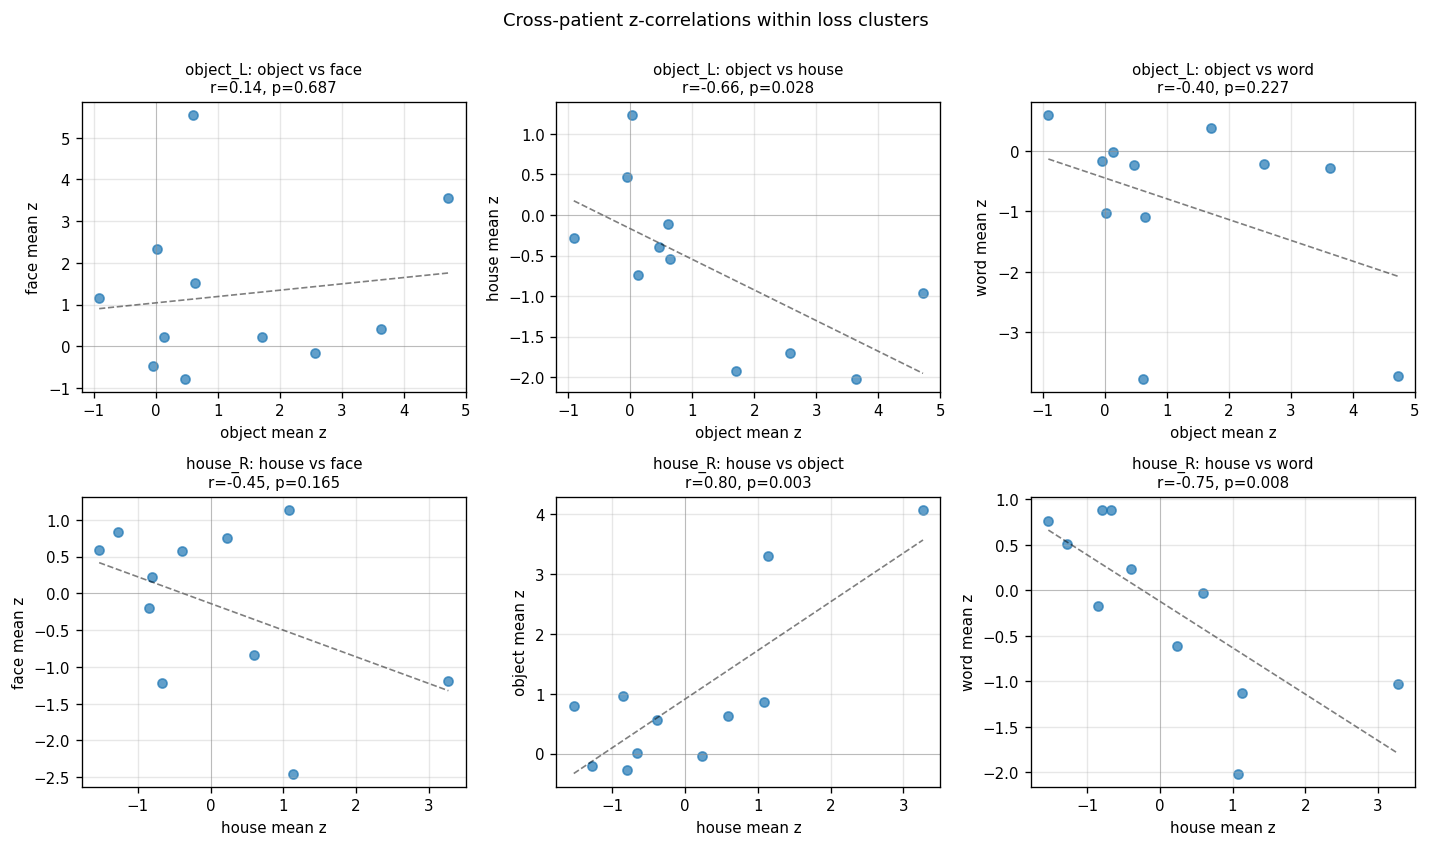

In [34]:
# ── Across-patient correlation within LOSS clusters: as donor falls, who rises? ──
LOSS_TESTS = [
    ('object_L', 'object', 'left',  'LH-intact: object_L cluster'),
    ('house_R',  'house',  'right', 'RH-intact: house_R cluster'),
]

print('Cross-subject correlation within each loss cluster (OTC patients only)')
print('Negative r = as donor z falls, other category z rises (takeover candidate)')
print('=' * 78)
for cluster, donor_cat, intact, label in LOSS_TESTS:
    sub_df = wide[(wide['cluster']==cluster) & (wide['group']=='OTC') &
                  (wide['intact_hemi']==intact)]
    print(f'\n{label}  n={len(sub_df)}')
    print(f'  {"vs":<12} {"Pearson r":>10} {"p":>8} {"Spearman r":>11} {"p":>8}')
    for other_cat in CATEGORIES_LIST:
        if other_cat == donor_cat:
            continue
        x = sub_df[donor_cat].values
        y = sub_df[other_cat].values
        m = ~(np.isnan(x) | np.isnan(y))
        if m.sum() < 3:
            continue
        r_p, p_p = pearsonr(x[m], y[m])
        r_s, p_s = spearmanr(x[m], y[m])
        sig = '*' if min(p_p, p_s) < .05 else ('†' if min(p_p,p_s) < .10 else '')
        print(f'  {donor_cat}~{other_cat:<9} {r_p:>10.3f} {p_p:>8.3f} '
              f'{r_s:>11.3f} {p_s:>8.3f} {sig}')

# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for row, (cluster, donor_cat, intact, label) in enumerate(LOSS_TESTS):
    sub_df = wide[(wide['cluster']==cluster) & (wide['group']=='OTC') &
                  (wide['intact_hemi']==intact)]
    others = [c for c in CATEGORIES_LIST if c != donor_cat]
    for col, other_cat in enumerate(others):
        ax = axes[row, col]
        x = sub_df[donor_cat].values
        y = sub_df[other_cat].values
        m = ~(np.isnan(x) | np.isnan(y))
        ax.scatter(x[m], y[m], s=30, alpha=0.7)
        if m.sum() >= 3:
            r, p = pearsonr(x[m], y[m])
            ax.set_title(f'{cluster}: {donor_cat} vs {other_cat}\nr={r:.2f}, p={p:.3f}', fontsize=9)
            z = np.polyfit(x[m], y[m], 1)
            xs = np.linspace(x[m].min(), x[m].max(), 50)
            ax.plot(xs, z[0]*xs + z[1], 'k--', alpha=0.5, lw=1)
        ax.set_xlabel(f'{donor_cat} mean z')
        ax.set_ylabel(f'{other_cat} mean z')
        ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
        ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
        ax.grid(alpha=0.3)
fig.suptitle('Cross-patient z-correlations within loss clusters', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / 'CS_takeover_correlations_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# ── Voxel-allegiance LH displacement test at configurable WTA threshold ──
WTA_THRESH_VA = 1.96   # try 1.96, 2.326 (default), 3.096 (Liu's)
CONSENSUS_PCT = 50

# Load VOTC masks (built by tfce_votc_contrasts.py)
votc_masks = {h: nib.load(str(TFCE_DIR / f'votc_{h}_mask.nii.gz')).get_fdata().astype(bool)
              for h in ('l', 'r')}

# Per-subject WTA in VOTC (first post session)
def compute_wta_for_sub(sub):
    ses = first_post_session(sub)
    if ses is None: return None
    vols = {}
    for cat, cope in CAT_COPES.items():
        p = cluster_z_path(sub, ses, ses, cope)
        if p is None: return None
        vols[cat] = nib.load(str(p)).get_fdata()
    stack = np.stack([vols[c] for c in CATEGORIES_LIST], axis=0)
    winner = np.argmax(stack, axis=0) + 1  # 1..4
    peak_z = np.max(stack, axis=0)
    winner = np.where(peak_z >= WTA_THRESH_VA, winner, 0)
    return {h: winner[votc_masks[h]] for h in ('l','r')}

sub_info_df = info.drop_duplicates('subject_id')[['subject_id']].merge(
    peak_u[['subject_id','group','intact_hemi']].drop_duplicates(), on='subject_id')

wta_by_sub = {}
for sub in sub_info_df['subject_id']:
    if sub in EXTRA_SKIP: continue
    w = compute_wta_for_sub(sub)
    if w is not None:
        wta_by_sub[sub] = w
print(f'WTA loaded for {len(wta_by_sub)} subjects')

# Control consensus per hemi
ctrl_subs = [s for s in wta_by_sub if sub_info_df[sub_info_df.subject_id==s]['group'].iloc[0]=='control']
otc_subs  = [s for s in wta_by_sub if sub_info_df[sub_info_df.subject_id==s]['group'].iloc[0]=='OTC']

consensus = {}
for h in ('l','r'):
    votes = np.zeros((wta_by_sub[ctrl_subs[0]][h].size, 5), dtype=int)
    for s in ctrl_subs:
        w = wta_by_sub[s][h]
        for c in range(5):
            votes[:,c] += (w==c).astype(int)
    cat_votes = votes[:,1:]
    max_v = cat_votes.max(axis=1)
    win = cat_votes.argmax(axis=1) + 1
    pct = max_v / len(ctrl_subs) * 100
    consensus[h] = np.where(pct >= CONSENSUS_PCT, win, 0)
    print(f'{h.upper()}H consensus: ' + ', '.join(
        f'{CATEGORIES_LIST[i]}={int((consensus[h]==i+1).sum())}' for i in range(4)))

# Displacement per (sub, hemi, src, dst)
def displacement_rows(sub_list, label):
    rows = []
    for s in sub_list:
        intact = sub_info_df[sub_info_df.subject_id==s]['intact_hemi'].iloc[0]
        for h in ('l','r'):
            cons = consensus[h]
            pat = wta_by_sub[s][h]
            for i, src in enumerate(CATEGORIES_LIST):
                src_mask = (cons == i+1)
                if src_mask.sum() == 0: continue
                in_src = pat[src_mask]
                n_src = src_mask.sum()
                for j, dst in enumerate(CATEGORIES_LIST):
                    if j == i: continue
                    pct = float((in_src == j+1).sum()) / n_src * 100
                    rows.append({'sub': s, 'group': label, 'intact_hemi': intact,
                                 'hemi': h, 'src': src, 'dst': dst, 'pct': pct})
    return pd.DataFrame(rows)

ctrl_d = displacement_rows(ctrl_subs, 'control')
otc_d  = displacement_rows(otc_subs,  'OTC')

# Perm test per (intact_hemi, hemi, src, dst)
def perm_test(a, b, n_perm=10000, seed=42):
    rng = np.random.default_rng(seed)
    pooled = np.concatenate([a, b])
    obs = a.mean() - b.mean()
    n_a = len(a)
    null = np.zeros(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        null[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    p = (np.abs(null) >= abs(obs)).mean()
    return obs, p

print(f'\nDisplacement at WTA threshold z>{WTA_THRESH_VA} (p<.10 shown):')
print(f'{"intact":>6} {"hemi":>5} {"src":>7} {"→":>2} {"dst":>7} '
      f'{"ctrl%":>6} {"OTC%":>6} {"Δ":>7} {"p":>7}')
print('-'*70)
for intact in ('left','right'):
    for h in ('l','r'):
        for src in CATEGORIES_LIST:
            for dst in CATEGORIES_LIST:
                if src == dst: continue
                otc_v = otc_d[(otc_d.intact_hemi==intact) & (otc_d.hemi==h) &
                              (otc_d.src==src) & (otc_d.dst==dst)]['pct'].values
                ctrl_v = ctrl_d[(ctrl_d.hemi==h) & (ctrl_d.src==src) &
                                (ctrl_d.dst==dst)]['pct'].values
                if len(otc_v) < 3 or len(ctrl_v) < 3: continue
                delta, p = perm_test(otc_v, ctrl_v)
                if p < .10:
                    sig = '*' if p < .05 else '†'
                    print(f'{intact:>6} {h:>5} {src:>7} {"→":>2} {dst:>7} '
                          f'{ctrl_v.mean():>6.2f} {otc_v.mean():>6.2f} '
                          f'{delta:>+7.2f} {p:>7.4f} {sig}')

WTA loaded for 69 subjects
LH consensus: face=184, house=1378, object=784, word=8
RH consensus: face=2, house=1134, object=2052, word=5

Displacement at WTA threshold z>1.96 (p<.10 shown):
intact  hemi     src  →     dst  ctrl%   OTC%       Δ       p
----------------------------------------------------------------------
  left     l    face  →  object  25.61  12.40  -13.21  0.0378 *
  left     l    face  →    word   0.66   6.03   +5.37  0.0246 *
  left     l   house  →  object  17.05   7.65   -9.40  0.0417 *
  left     l    word  →    face   3.95  14.77  +10.83  0.0789 †
  left     r   house  →    face   1.33   3.46   +2.13  0.0206 *
  left     r   house  →    word   1.91   3.99   +2.08  0.0916 †
  left     r  object  →    face   9.72  18.52   +8.81  0.0098 *
  left     r    word  →   house  13.16  41.82  +28.66  0.0008 *
 right     l    face  →   house   6.16   0.84   -5.32  0.0695 †
 right     l    face  →    word   0.66  16.80  +16.14  0.0000 *
 right     l   house  →    word   1.83